---
numbering: false
---

# 1.2. Squared Loss and the Constant Model

## Motivation
Suppose that you're looking for an off campus apartment for next year. Unfortunately, none of them are in your price range, so you decide to live with your parents in Detroit and commute. To see if you can save some time on the road each day, you keep track of how long it takes for you to get to school.

In [1]:
import pandas as pd

df = pd.read_csv('data/commute-times.csv')
df[['date', 'day', 'departure_hour', 'minutes']].head()

,date,day,departure_hour,minutes
0,5/15/2023,Mon,10.816667,68.0
1,5/16/2023,Tue,7.750000,94.0
2,5/22/2023,Mon,8.450000,63.0
3,5/23/2023,Tue,7.133333,100.0
4,5/30/2023,Tue,9.150000,69.0


This is a real dataset, collected by [Joseph Hearn](https://github.com/jahearn3/commuting), except he lived in Seattle, not Metro Detroit. The full dataset contains more columns than are shown above, but we'll focus on these few for now.

Our goal is to predict commute times, stored in the `minutes` column. This is our $y$ variable. The natural first input variable, or **feature**, to consider, is `departure_hour`. This is our $x$ variable.

We'll use the subscript $i$ to index the $i$th data point, for $i = 1, 2, \ldots, n$. Using the dataset above, $x_1 = 10.816667$ and $y_1 = 68$, for instance.

Departure hours are stored as decimals, but correspond to times of the day. For example, 7.75 corresponds to 7:45 AM, and 10.816667 corresponds to 10:49 AM.

$$
\begin{align*}
10.816667 &= 10 + 0.816667 \text{ hours} \\
          &= 10 \text{ hours} + 0.816667 \cdot 60 \text{ minutes} \\
          &= 10 \text{ hours} + 49 \text{ minutes}
\end{align*}
$$

<!-- Ultimately, we're looking for a function $h$ such that:

$$

$$\text{predicted commute time}_i = h(\text{departure hour}_i)$$

where $i$ indexes the $i$th data point. We'll use the notation $h(x_i)$ to denote the predicted value of $y_i$ given $x_i$. -->

Before we get any further, we should **look** at our data. Since we're working with two quantitative variables, we should draw a scatter plot.

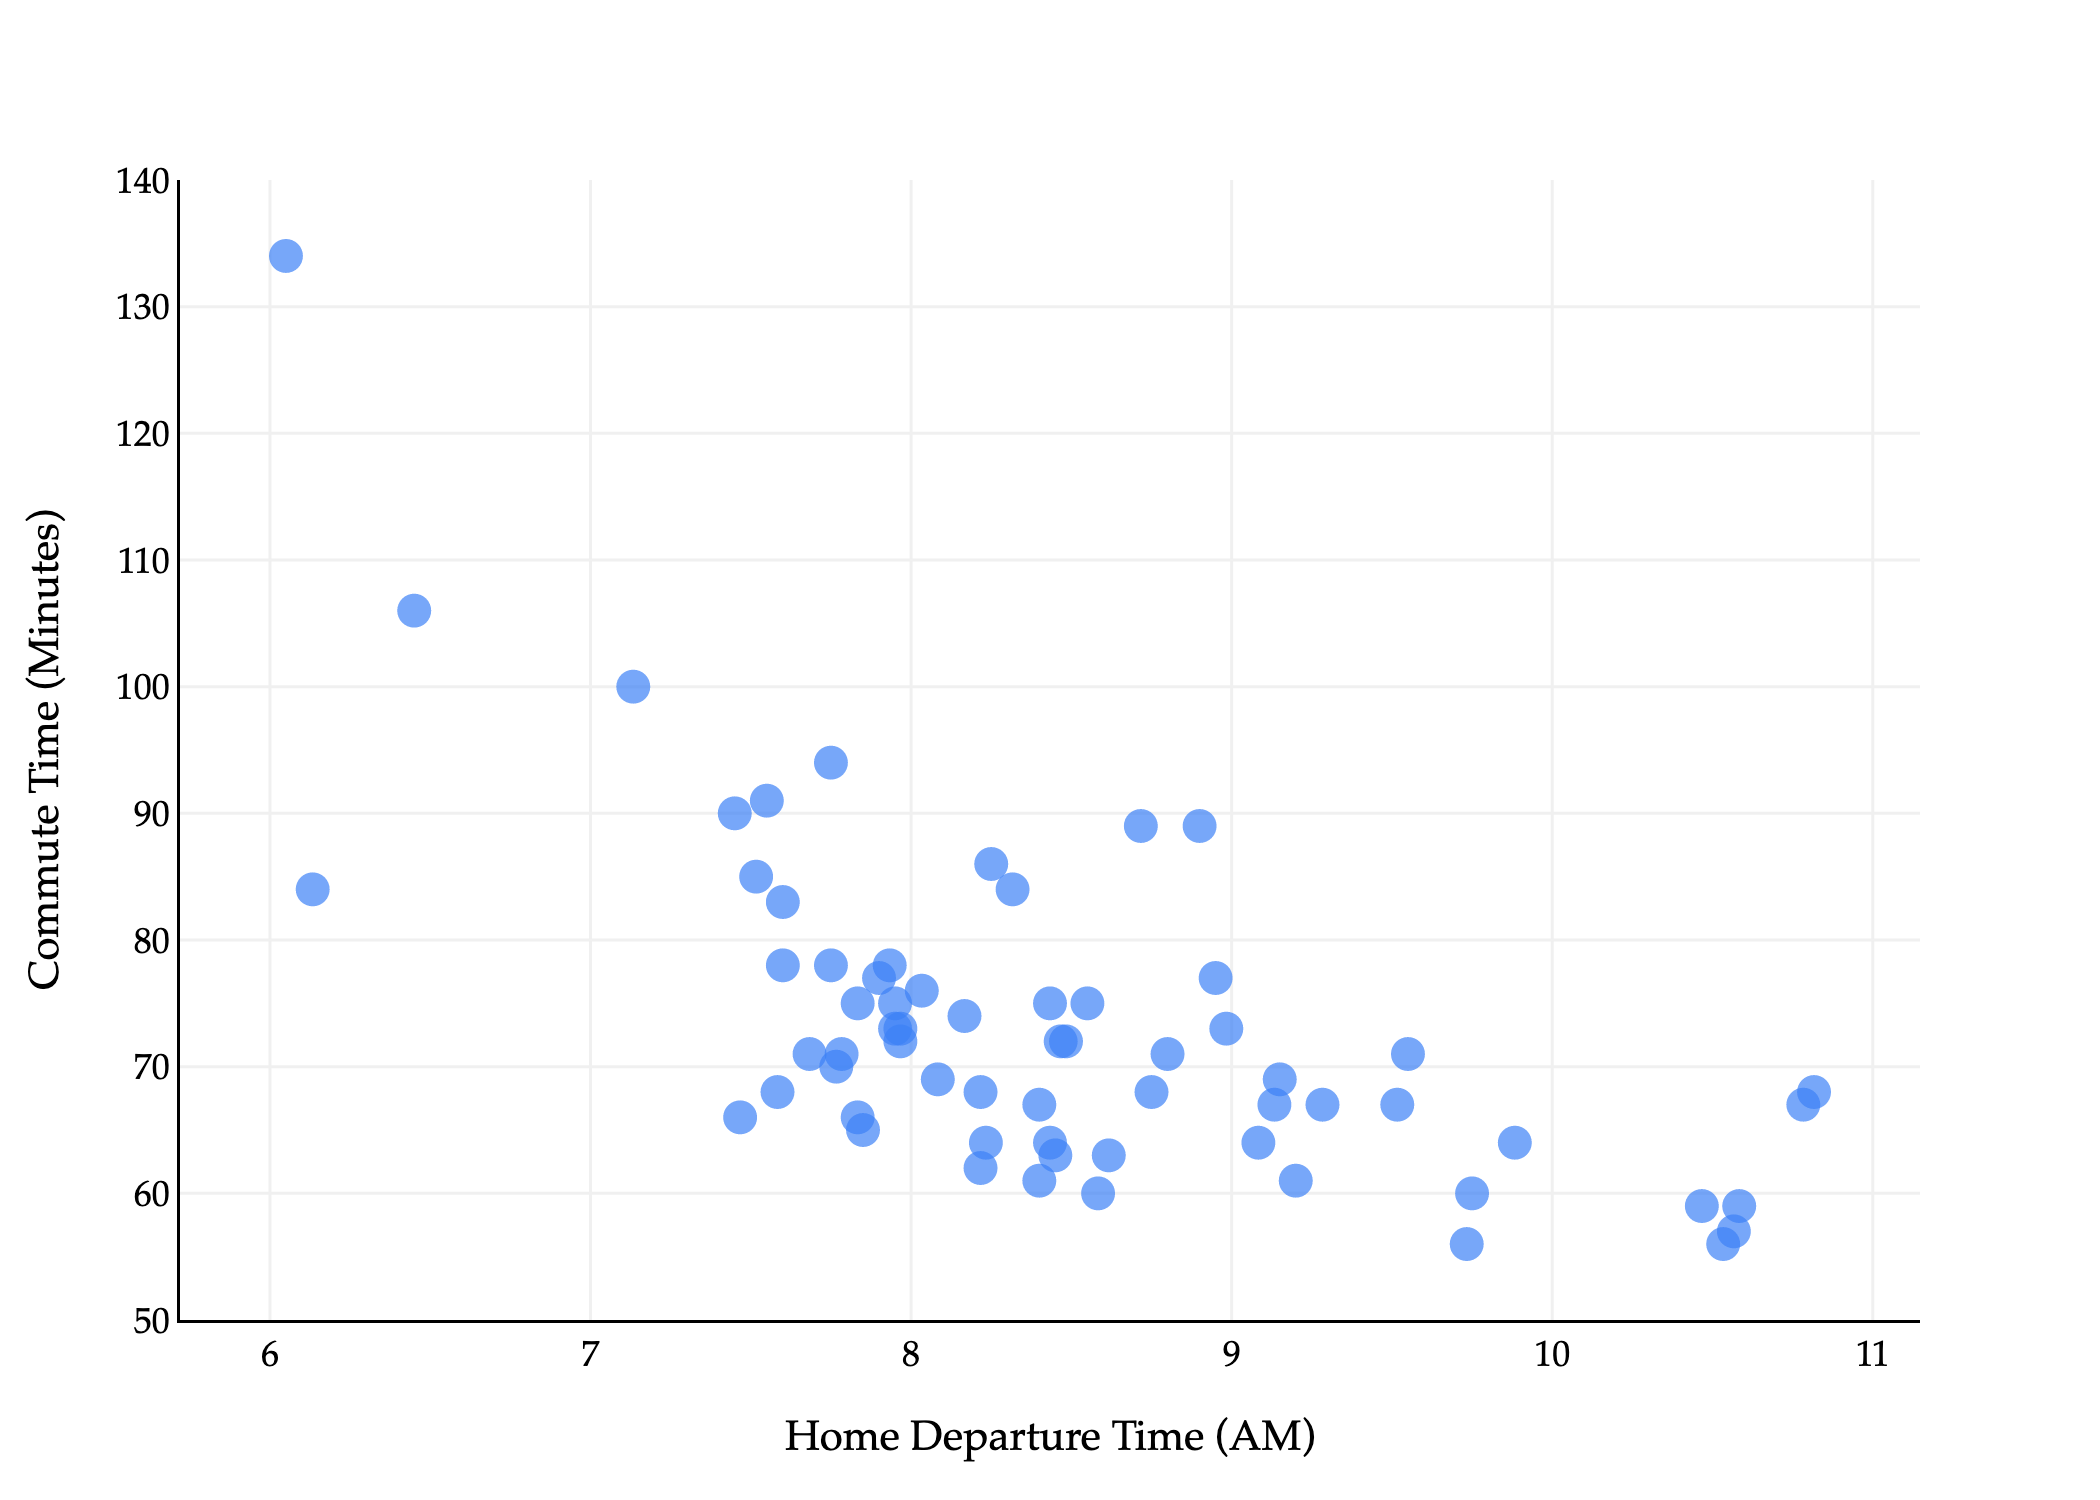

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)

There's a general downward trend: the later the departure time, the lower the commute time tends to be.

Again, our goal is to predict commute time given departure hour. That is, we'd like to build a useful function $h$ such that:

$$\text{predicted commute time}_i = h(\text{departure hour}_i)$$

This is a **regression** problem, because the variable we are predicting – commute time – is quantitative.

To build this function, the approach we'll take is the machine learning approach – that is, to **learn a pattern from the dataset** that we've collected. (This is not the only approach one could take – we could build the function $h$ however we want.)

However, in order to learn a pattern from the dataset that we've collected, we need to make an important assumption.

:::{attention} The Key Assumption in Machine Learning
In order for the patterns we learn from a dataset to be useful, **we must assume that future data will look like past data!**
:::

We don't really need our function $h$ to make good predictions on the dataset that we've already collected. We know the actual commute times on day 1, day 2, ..., day $n$. In other words, we're working with a **labeled** dataset, in which we're given the values of $y_1, y_2, \ldots, y_n$.

What we **do** need is for our function $h$ to make good predictions on **unseen** data from the future, i.e. for future commutes, the ones we don't know about yet. This is the only way our function $h$ will be practically useful.

But, if the future doesn't resemble the past, the patterns we learn from the past will not be **generalizable** to the future. For example, if a new highway between Detroit and Ann Arbor gets built, the patterns previously learned won't necessarily still exist. This idea of generalizability is key, so keep it in mind even if we're not explicitly talking about it.

---

## Models

I've used the word "model" loosely, but let's give it a formal definition.

:::{note} Definition: Model
A **model** is a set of assumptions about how data were generated.
:::

> "All models are wrong, but some are useful." - [George Box](https://en.wikipedia.org/wiki/George_E._P._Box)

My interpretation of George Box's famous quote is that no matter how complex a model is, it will never be 100% correct, so sometimes – especially when we're starting our machine learning journey – it's better to use a simpler model that is also wrong but **interpretable**.

We gain value from simple models all the time. In a physics class, you may have learned that acceleration due to gravity is $9.81 \text{ m/s}^2$ towards the center of the Earth. This is not fully accurate – think about how parachutes work, for example – but it's still a useful approximation, and one that is relatively easy to understand. A related idea is [Occam's razor](https://en.wikipedia.org/wiki/Occam%27s_razor), which states that the simplest explanation of a phenomenon is often the best.

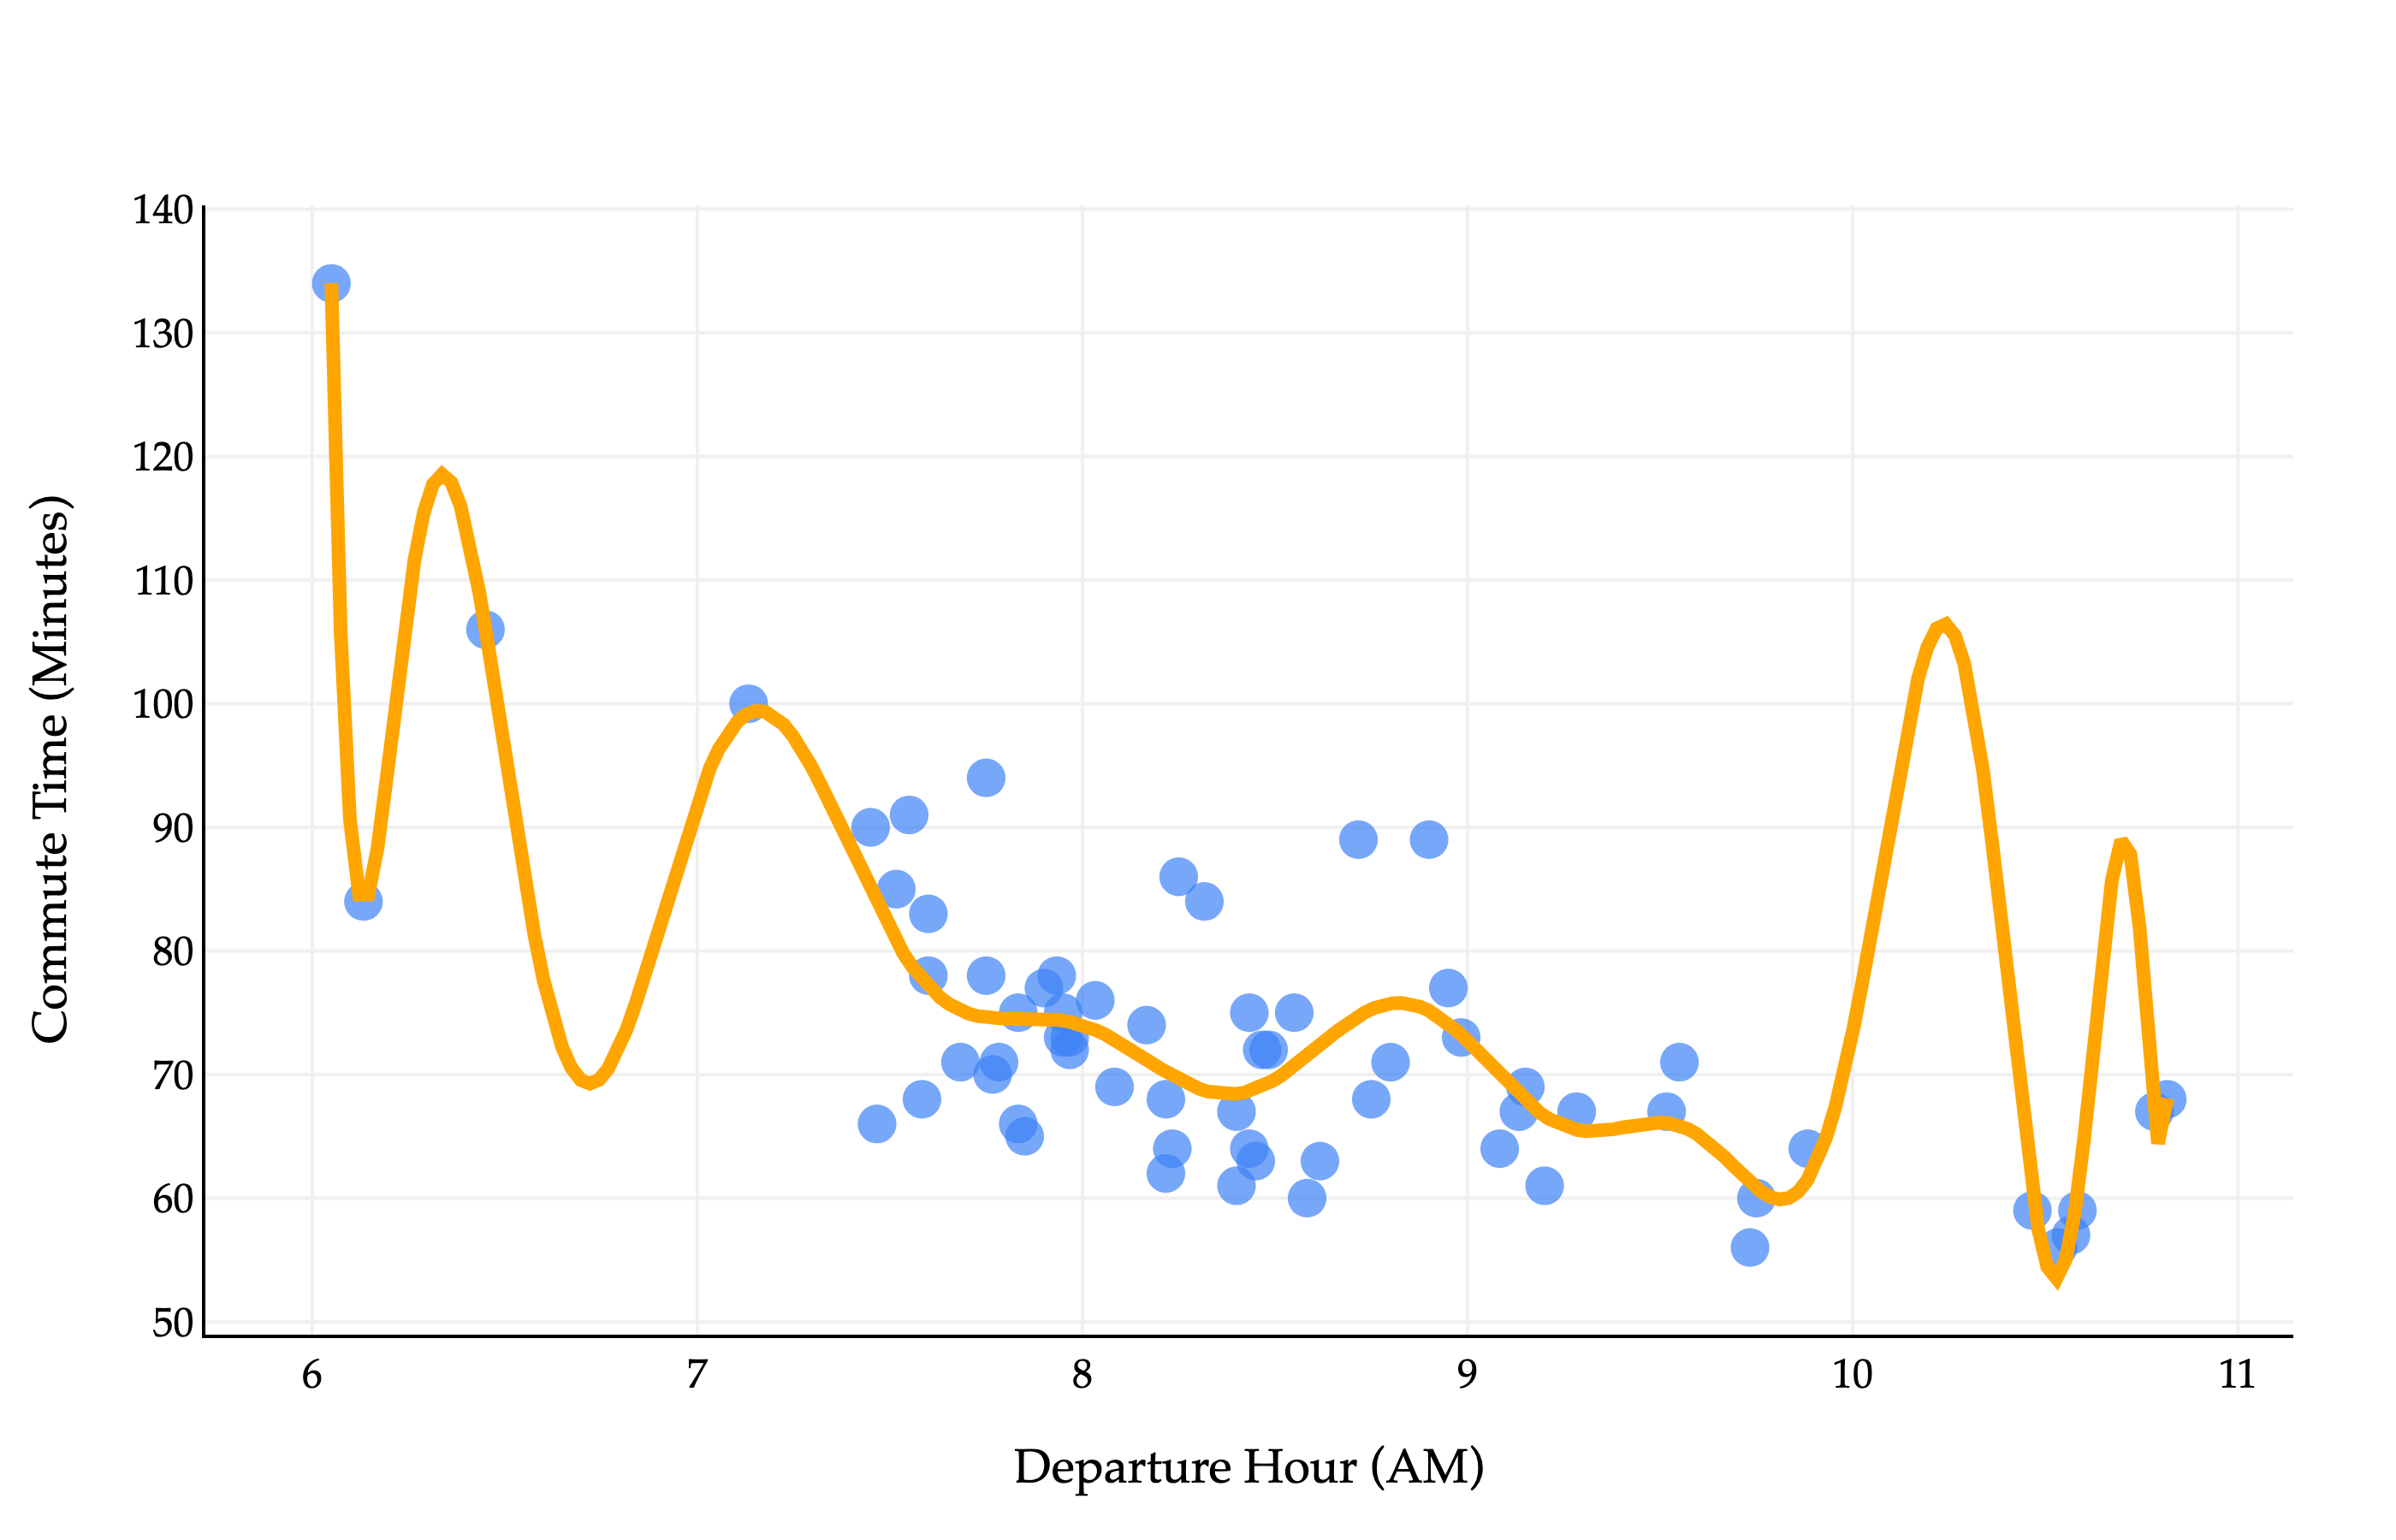

In [52]:
import pandas as pd
import numpy as np
import plotly.express as px
import warnings

warnings.simplefilter('ignore', np.RankWarning)

df = pd.read_csv('data/commute-times.csv')

x = df['departure_hour'].values
y = df['minutes'].values

coeffs = np.polyfit(x, y, deg=40)
poly = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = poly(x_fit)

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.add_traces(
    px.line(
        x=x_fit,
        y=y_fit
    ).data
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0, selector=dict(mode='markers'))
fig.update_traces(line_color='orange', line_width=4, selector=dict(mode='lines'))
fig.update_xaxes(
    title='Departure Hour (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=700,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=4)

Above, you'll see a degree-40 polynomial fit to our dataset. We'll learn how to build such polynomials throughout the semester.

At first glance, it looks to be quite accurate, albeit complex. In fact, it's a little too complex, and the phenomenon we see above is called **overfitting**. For $x_i$'s in the dataset that we collected, sure, the polynomial will make accurate predictions, but for any $x_i$'s that don't match the exact pattern in the dataset, the predictions will be off. (For example, it's unlikely that commutes will take 110 minutes around 10:15AM, but that's what the model predicts.) This polynomial model wouldn't generalize well to unseen data.

If we look at the scatter plot closely, it seems reasonable to start with a line of best fit, much like you may have seen in a statistics class. In fact, we'll start with something even more simple than that. But first, some notation.

---

## Hypothesis Functions

:::{note} Definition: Hypothesis Function
A **hypothesis function** $h$ takes in an $x_i$ as an input and returns a predicted $y_i$.

$$\text{predicted } y_i = h(x_i)$$
:::

The hypothesis functions we'll study have **parameters**, usually denoted by $w$, which describe the relationship between the input and output. The two hypothesis functions we'll study to start with are:

1. **Constant model**: $h(x_i) = w$
1. **Simple linear regression model**: $h(x_i) = w_0 + w_1 x_i$

We'll study the constant model first, but it's easier to understand the role of parameters in the simple linear regression model. As we'll soon see, this linear regression model is called "simple" because it only takes in one input variable, $x_i$. "Multiple" linear regression models take in multiple features.

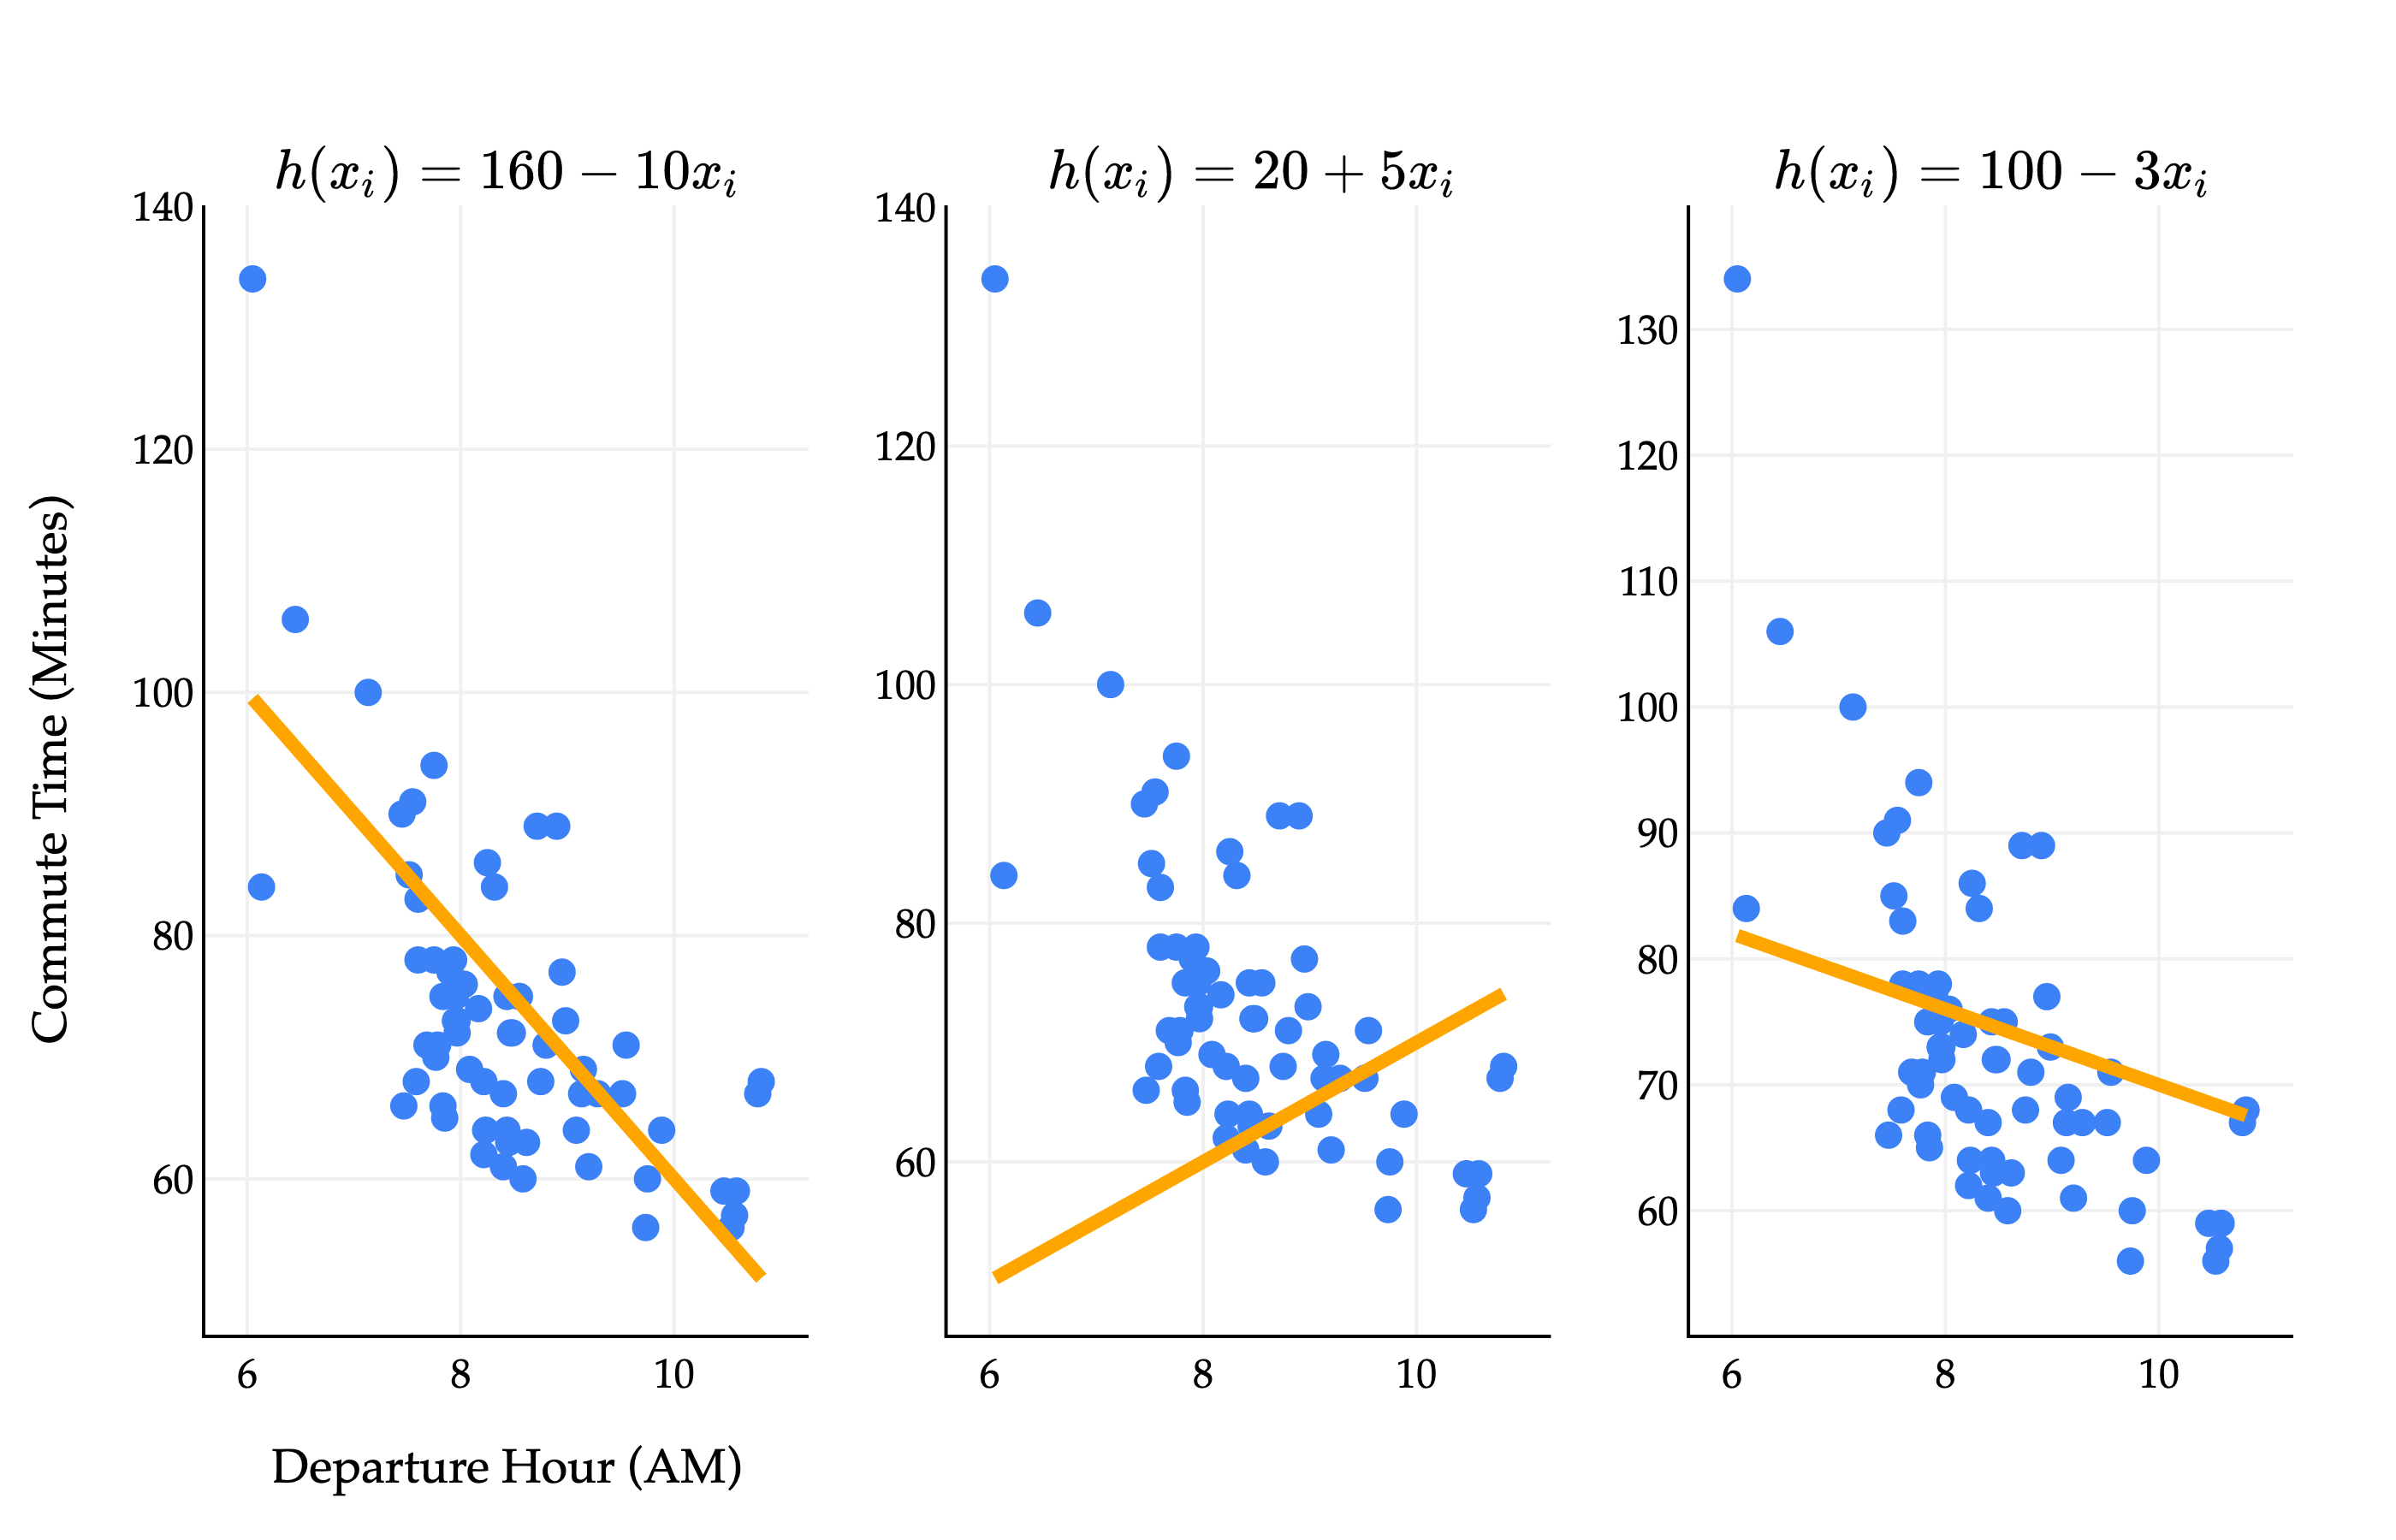

In [55]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

x = df['departure_hour'].values
y = df['minutes'].values

# Define (slope, intercept) pairs for three lines
lines = [
    (-10, 160),      # h(x) = 70
    (5, 20),      # h(x) = 5x + 20
    (-3, 100)     # h(x) = -3x + 100
]

# Titles for each subplot
subplot_titles = [
    r"$h(x_i) = 160 - 10x_i$",
    r"$h(x_i) = 20 + 5x_i$",
    r"$h(x_i) = 100 - 3x_i$"
]

fig = make_subplots(rows=1, cols=3, subplot_titles=subplot_titles)

x_line = np.linspace(x.min(), x.max(), 100)

for i, (slope, intercept) in enumerate(lines, start=1):
    fig.add_trace(
        go.Scatter(
            x=x, 
            y=y, 
            mode='markers', 
            name='Data', 
            marker=dict(
                color='#3D81F6', 
                size=8,
            ),
            showlegend=False
        ),
        row=1, col=i
    )

    y_line = slope * x_line + intercept
    fig.add_trace(
        go.Scatter(
            x=x_line, 
            y=y_line, 
            mode='lines', 
            name=f'$h(x)={slope}x+{intercept}$', 
            line=dict(color='orange', width=4)
        ),
        row=1, col=i
    )

fig.update_layout(
    showlegend=False,
    xaxis_title='Departure Hour (AM)',
    yaxis_title='Commute Time (Minutes)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=700,
    height=450,
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        bordercolor='rgba(0,0,0,0)',
        font=dict(size=14)
    ),
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.show(renderer='png', scale=4)

$h(x_i) = w_0 + w_1 x_i$ represents the equation of a line, where $w_0$ is the intercept and $w_1$ is the slope. Above, we see that different choices of parameters $w_0$ and $w_1$ result in different lines. The million dollar question is: **among all of the infinitely many choices of $w_0$ and $w_1$, which one is the best?**

To fully answer that, we'll have to wait until [Chapter 2.2](../02_simple_linear_regression/02-partial-derivatives.ipynb). Surprisingly, that answer involves multivariable calculus. 

For now, let's return to the constant model, $h(x_i) = w$. The constant model predicts the same value for all $x_i$'s, and looks like a flat line.

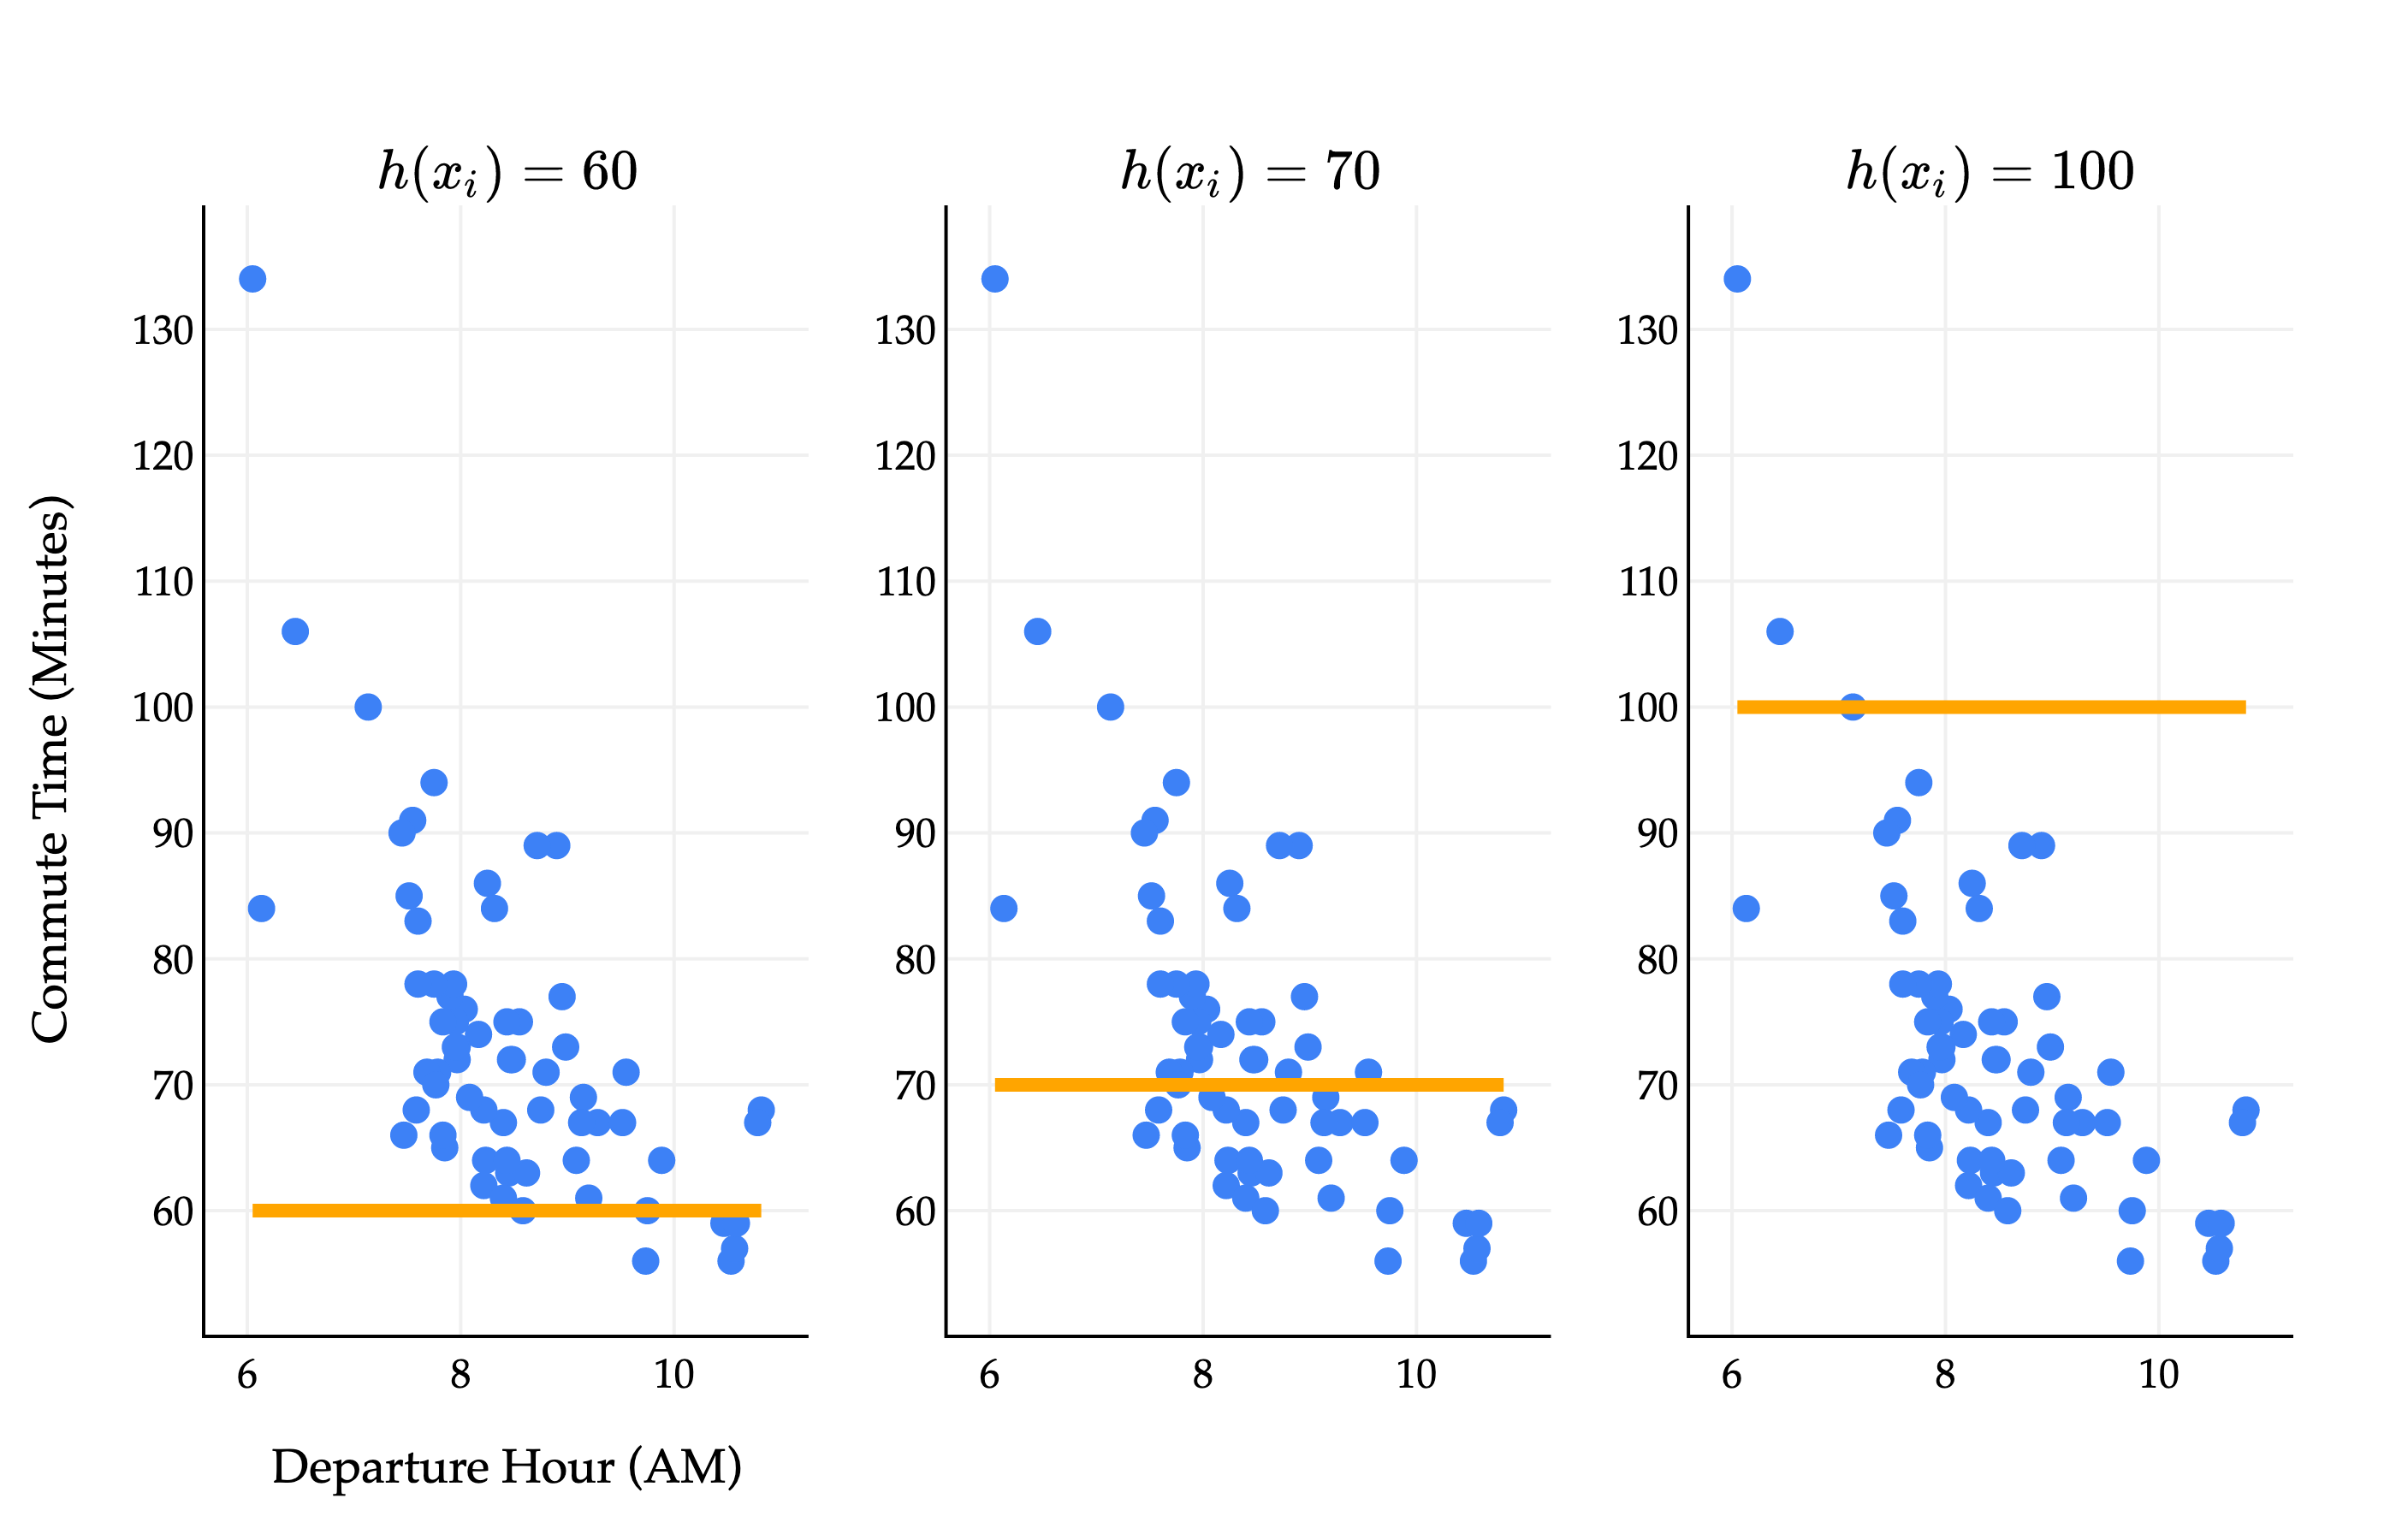

In [33]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')
constants = [60, 70, 100]


x = df['departure_hour'].values
y = df['minutes'].values

fig = go.Figure()

fig = make_subplots(rows=1, cols=3, subplot_titles=['$h(x_i)=60$', '$h(x_i)=70$', '$h(x_i)=100$'])

for i in range(1, 4):
    fig.add_trace(
        go.Scatter(
            x=x, 
            y=y, 
            mode='markers', 
            name='Data', 
            marker=dict(
                color='#3D81F6', 
                size=8,
            ),
            showlegend=False
        ),
        row=1, col=i
    )

    fig.add_trace(
        go.Scatter(
            x=x, 
            y=[constants[i-1]] * len(x), 
            mode='lines', 
            name=f'$h(x_i)={constants[i-1]}$', 
            line=dict(color='orange', width=4)
        ),
        row=1, col=i
    )

fig.update_layout(
    showlegend=False,
    xaxis_title='Departure Hour (AM)',
    yaxis_title='Commute Time (Minutes)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=700,
    height=450,
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        bordercolor='rgba(0,0,0,0)',
        font=dict(size=14)
    ),
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.show(renderer='png', scale=4)

We'll use the constant model for the rest of this section to illustrate core ideas in machine learning, and will move to more sophisticated models in [Chapter 2.1](../02_simple_linear_regression/01-overview.ipynb).

If we're forced to use a constant model, it's clear that some choices of $w$ (the height of the line) are better than others. $w=100$ yields a flat line that is far from most of the data. $w=60$ and $w=70$ seem like much more reasonable predictions, but how we can quantify which one is better, and which $w$ would be the best?

Since the constant model doesn't depend on departure hours $x_i$, we can instead draw a histogram of just the true commute times.

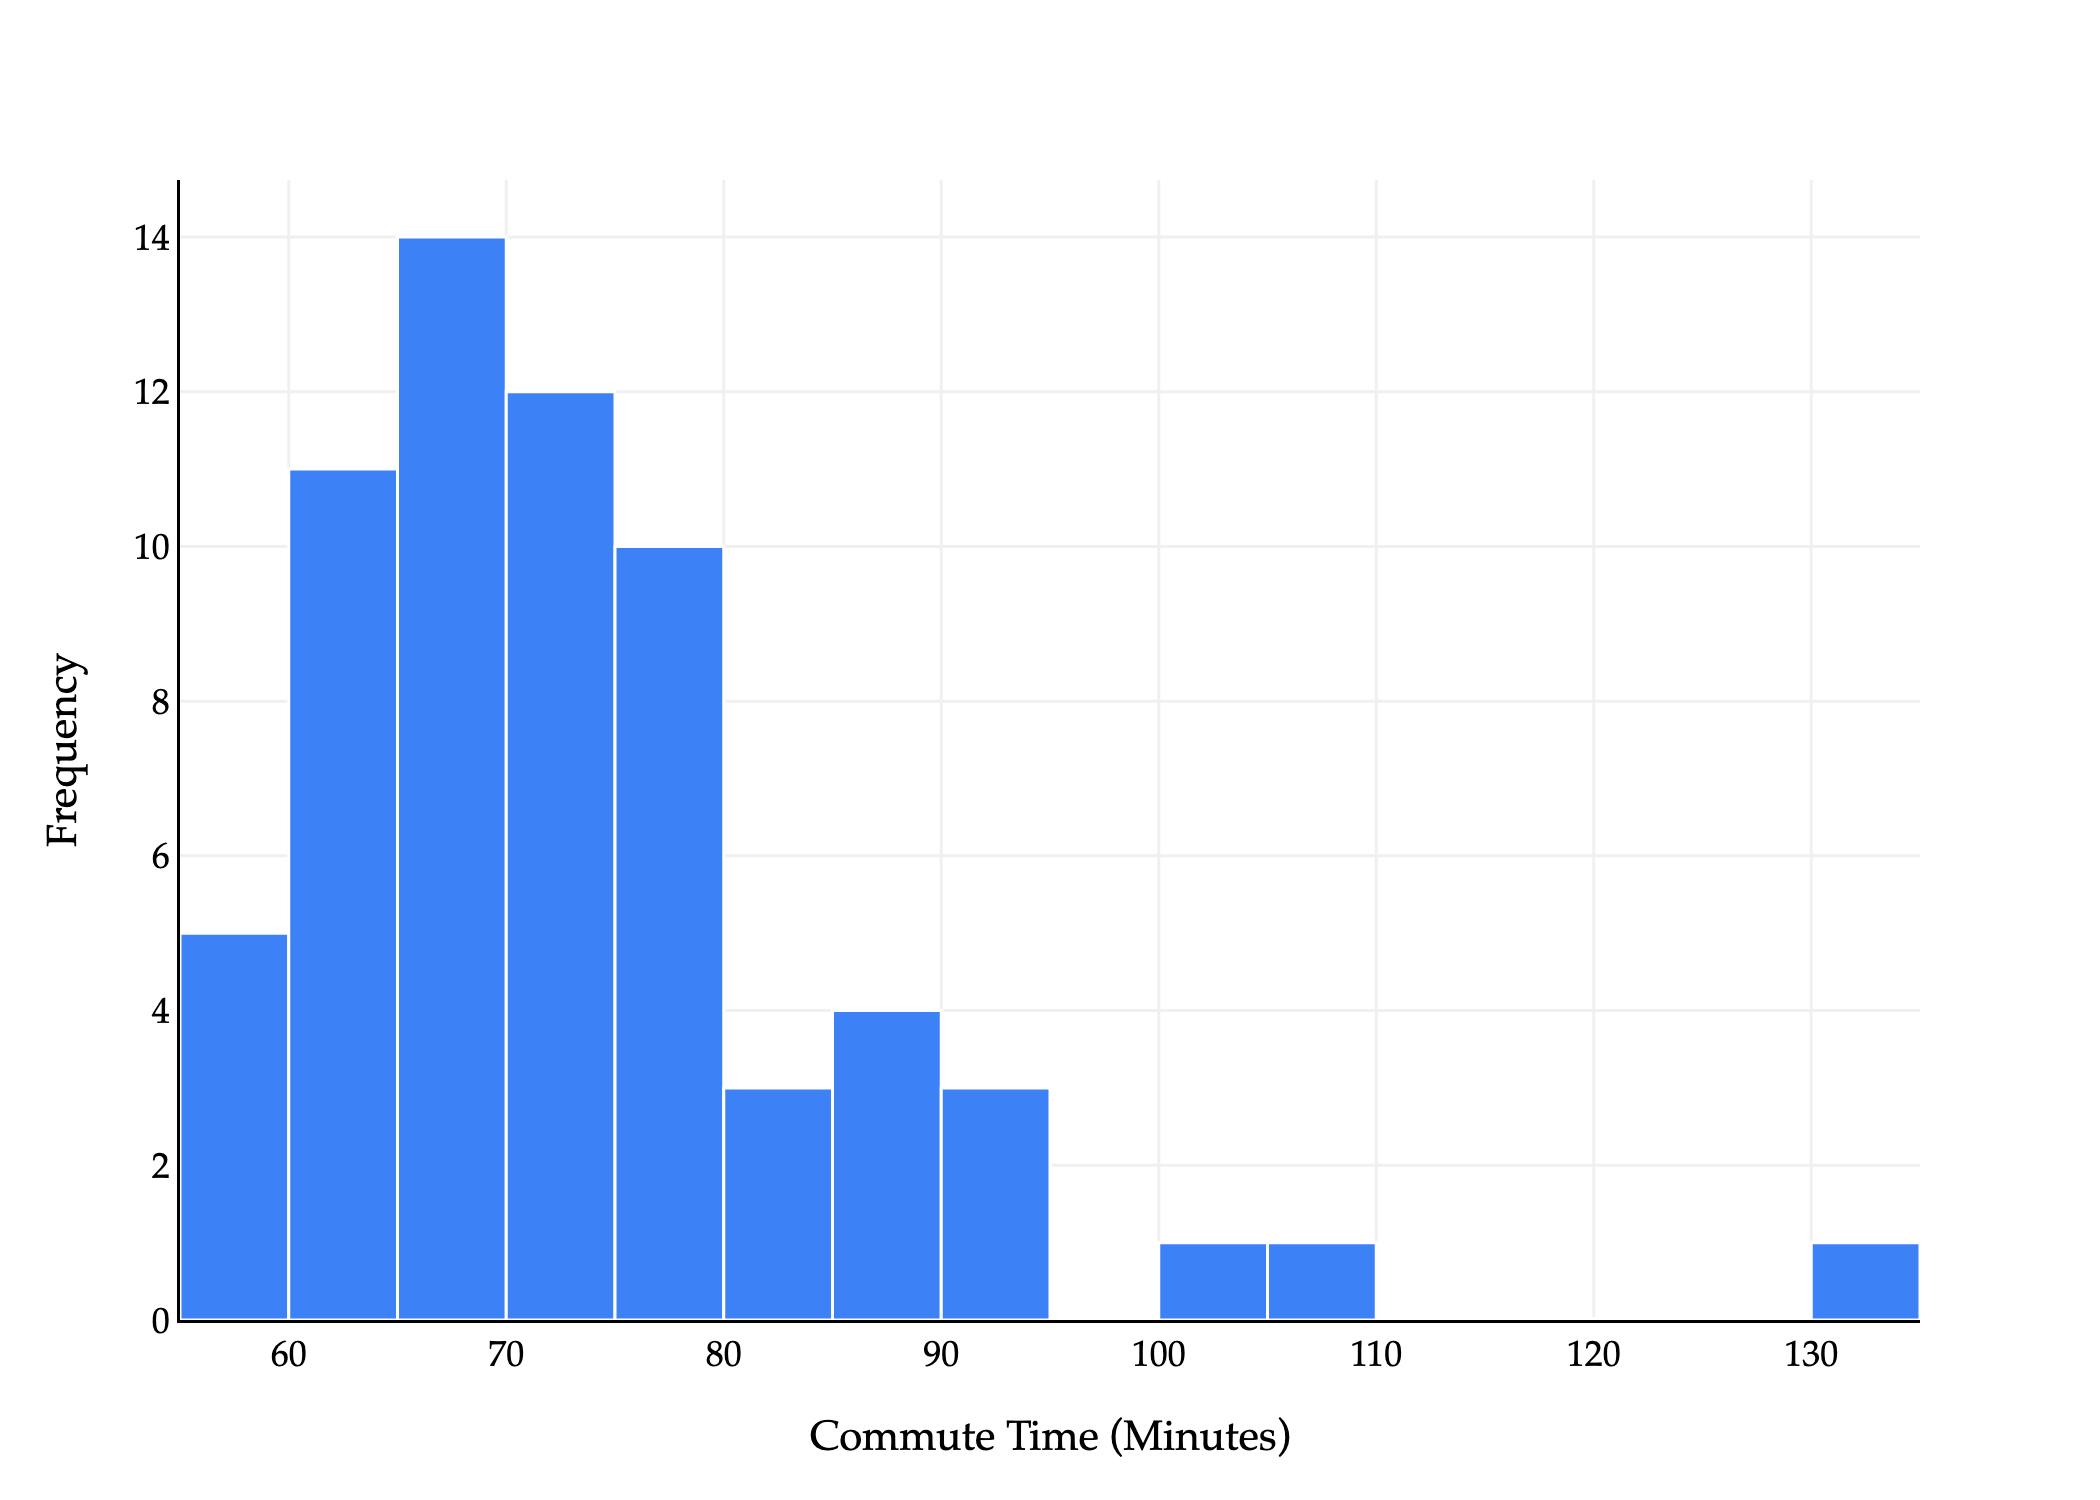

In [34]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.histogram(
    df, 
    x='minutes', 
    nbins=20,
)
fig.update_xaxes(
    title='Commute Time (Minutes)', 
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Frequency', 
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_traces(marker_line_color='white', marker_line_width=1, marker_color="#3D81F6")
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)

An equivalent way of phrasing the problem is, which constant $w$ best summarizes the histogram above? Most commute times seem to be in the 60 to 80 range, so somewhere there makes sense. How can we be more precise?

---

## Loss Functions

To illustrate, let's consider a small dataset of only 5 commute times.

$$y_1=72, \quad y_2=90, \quad y_3=61, \quad y_4=85, \quad y_5=92$$

If asked to find the constant that best summarizes these 5 numbers, you might think of the mean or median, which are common **summary statistics**. There are other valid choices too, like the mode, or halfway between the minimum and maximum, or the most recent. What we need is a way to compare these choices.

A **loss function** quantifies how bad a prediction is for a single data point.
- If our prediction is __close__ ✅ to the actual value, we should have __low__ loss.
- If our prediction is __far__ ❌ from the actual value, we should have __high__ loss.

We'll start by computing the error for a single data point, defined as the difference between an actual $y$-value and its corresponding predicted $y$-value.
$$e_i={\color{3D81F6}y_i}-{\color{orange}h(x_i)}$$
where ${\color{3D81F6}y_i}$ is the <span style="color:#3D81F6; font-weight:bold">actual value</span> and ${\color{orange}h(x_i)}$ is the <span style="color:orange; font-weight:bold">predicted value</span>. 

Could this be a loss function? Let's think this through. Suppose we have the true commute time $y_i=80$.

- If I predict <span style="color:orange; font-weight:bold">75</span>, $e_i=80-\textcolor{orange}{75}=5$.
- If I predict <span style="color:orange; font-weight:bold">72</span>, $e_i=80-\textcolor{orange}{72}=8$.
- If I predict <span style="color:orange; font-weight:bold">100</span>, $e_i=80-\textcolor{orange}{100}=-20$.

A lower error is better, so 75 (error of 5) is a better prediction than 72 (error of 8). 100 seems to be the worst of the three predictions, but technically has the smallest error (-20). The issue is that some errors are positive and some are negative, and so it's hard to compare them directly.

So ideally, a loss function shouldn't have negative outputs. How can we take these errors, in which some are positive and some are negative, and enforce that they're all positive?

### Squared Loss

The most common solution to the problem of negative errors is to square each error. This gives rise to the first loss function we'll explore, and arguably the most common loss function in machine learning: **squared loss**.

The squared loss function, $L_\text{sq}$, computes $({\color{3D81F6}\text{actual}}-{\color{orange}\text{predicted}})^2$. That is:

$$L_\text{sq}({\color{3D81F6}y_i}, {\color{orange}h(x_i)})=({\color{3D81F6}y_i}-{\color{orange}h(x_i)})^2$$

Why did we square instead of take the absolute value? Absolute loss is a perfectly valid loss function – in fact, we'll study it in [Chapter 1.3](03-absolute-loss.ipynb) – and different loss functions have different pros and cons. That said, squared loss is a good first choice because:
- The resulting optimization problem is differentiable, as we'll see in just a few moments.
- It has a nice relationship to the normal distribution in statistics, as we'll see in Chapter 6, at the end of the course.

Let's return to our small example dataset of 5 commute times.

$$y_1=72, \quad y_2=90, \quad y_3=61, \quad y_4=85, \quad y_5=92$$

How can we use squared loss to compare two choices of $w$, say $w=85$ (the median) and $w=80$ (the mean)? Let's draw a picture (in which the $x$-axis positions of each point are irrelevant, since we're not using departure hours).

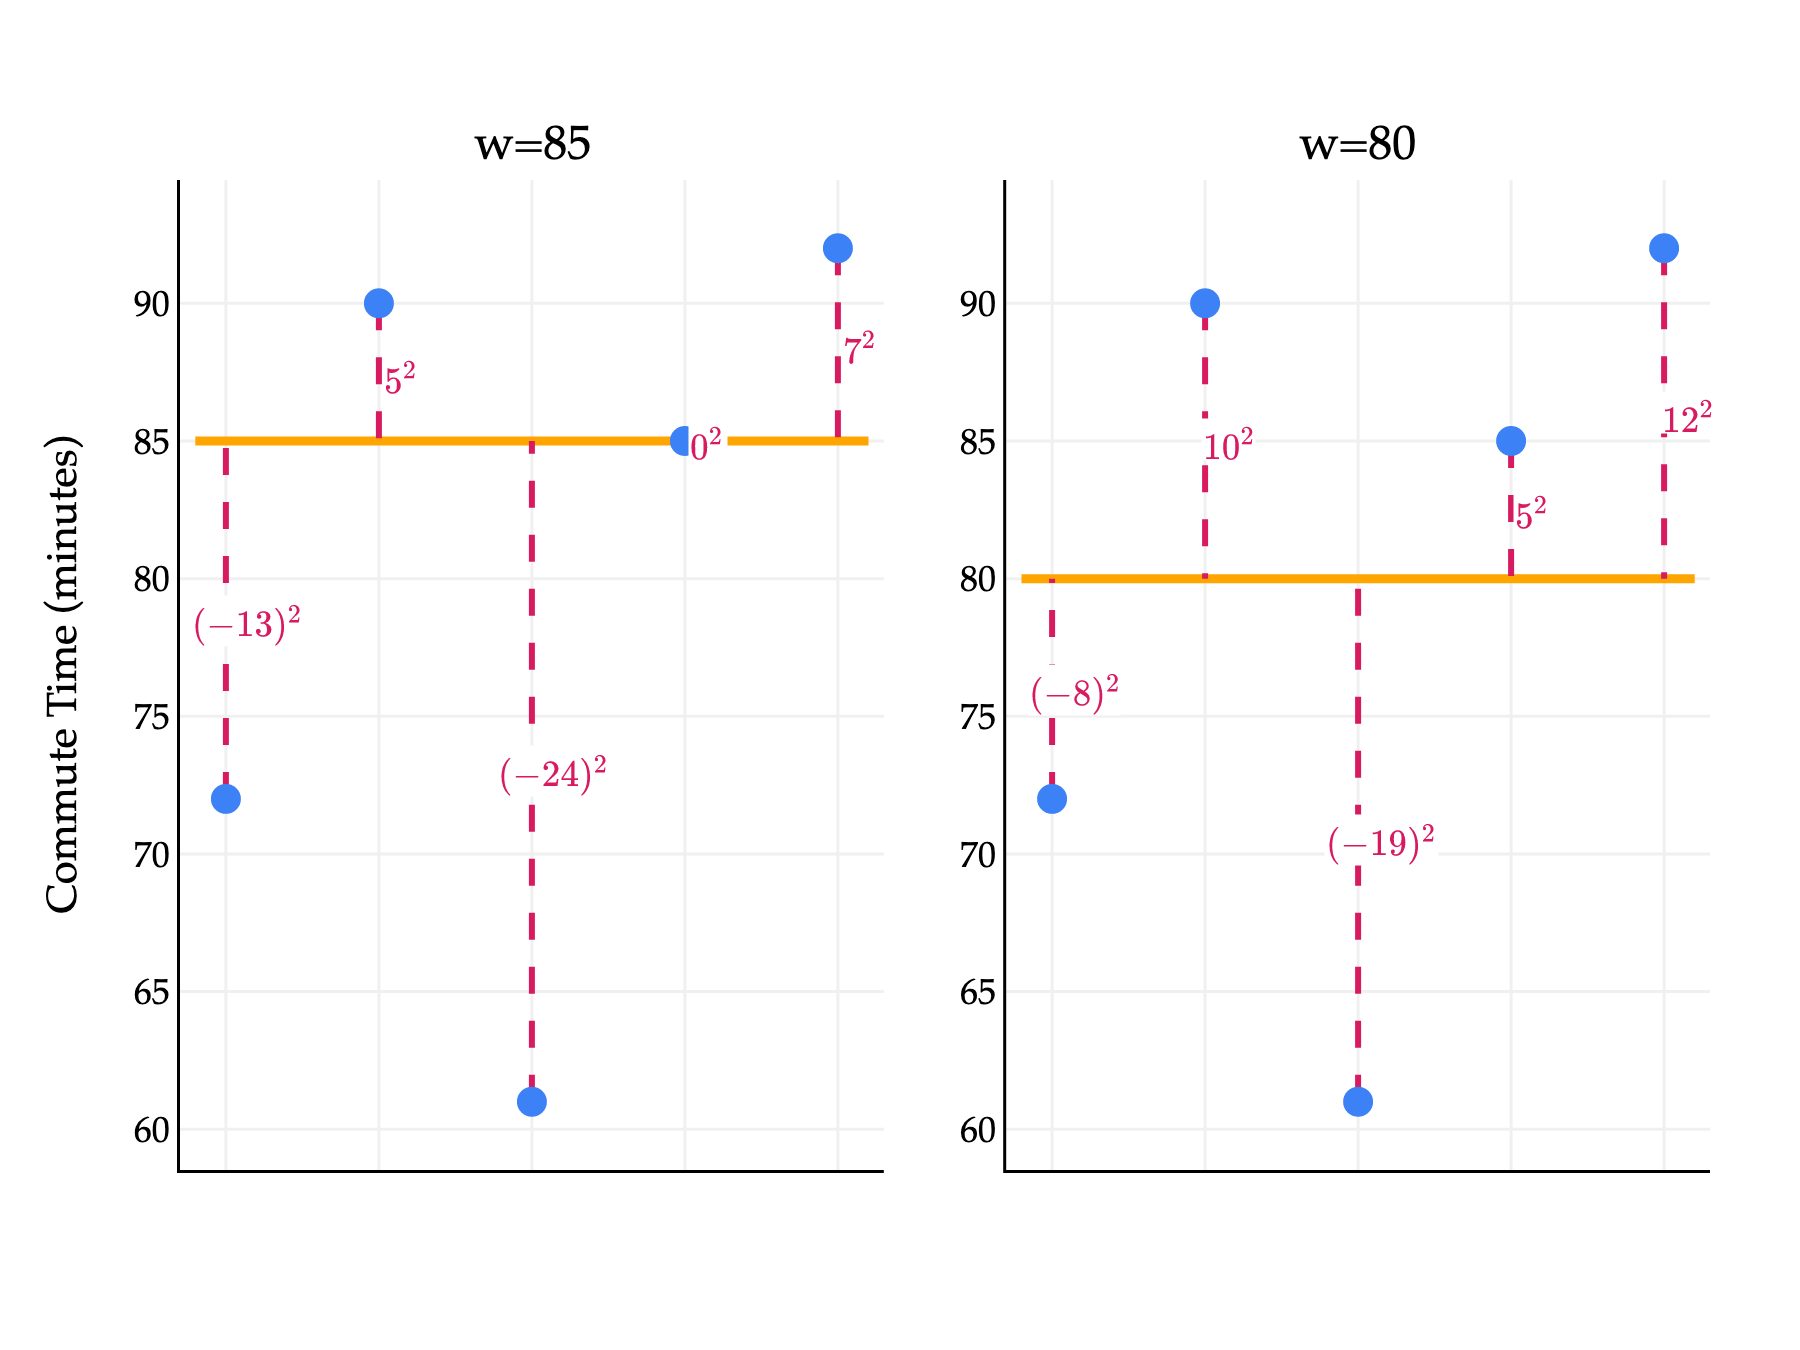

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

y = np.array([72, 90, 61, 85, 92])
preds = [85, 80]  # predictions changed to 85 and 80

# create 1 row, 2 columns with reduced horizontal domain for each subplot
fig = make_subplots(
    rows=1, 
    cols=2, 
    subplot_titles=[f"w={p}" for p in preds],
    horizontal_spacing=0.08  # increase spacing between subplots to shrink each horizontally
)

for j, h in enumerate(preds):
    losses = y - h  # show the loss value, not squared loss

    # Horizontal prediction line
    fig.add_trace(
        go.Scatter(
            x=[0.8, 5.2],  # shrink x-range to compress horizontally
            y=[h, h],
            mode="lines",
            line=dict(color="orange", width=3),
            name=f"$w={h}$",
            showlegend=False
        ),
        row=1, col=j+1
    )

    # Vertical dashed error lines
    for i, yi in enumerate(y):
        fig.add_trace(
            go.Scatter(
                x=[i+1, i+1],
                y=[yi, h],
                mode="lines",
                line=dict(color="#D81B60", width=2, dash="dash"),
                showlegend=False
            ),
            row=1, col=j+1
        )

    # Data points
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, 6),
            y=y,
            mode="markers",
            marker=dict(size=10, color="#3D81F6"),
            name=r"$y_i$",
            showlegend=False
        ),
        row=1, col=j+1
    )

    # Annotations for losses (show as loss, no arrow, place nearby)
    for i, (yi, loss) in enumerate(zip(y, losses)):
        fig.add_annotation(
            x=i+1 + 0.15,  # slight offset to the right
            y=(yi + h) / 2,
            text=f"${'(' + str(int(loss)) + ')' if loss < 0 else str(int(loss))}^2$",
            showarrow=False,
            bgcolor="white",
            font=dict(size=12, family="Palatino", color="#D81B60"),
            row=1, col=j+1
        )

# Shared axis styling
fig.update_xaxes(
    range=[0.7, 5.3],  # shrink x-axis range for each subplot
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor="#f0f0f0",
    showline=True,
    linecolor="black",
    linewidth=1
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="#f0f0f0",
    showline=True,
    linecolor="black",
    linewidth=1
)

# Layout
fig.update_layout(
    showlegend=True,
    yaxis_title="Commute Time (minutes)",
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=600,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.show(renderer="png", scale=3)


Each output of $L_\text{sq}$, shown in <span style="color:#D81B60; font-weight:bold">pink</span>, describes the quality of a prediction for a single data point. For example, in the left plot above, the annotated $(-13)^2$ came from an actual value of 72 and a predicted value of 85:

$$L_\text{sq}({\color{3D81F6}72}, {\color{orange}85}) = ({\color{3D81F6}72}-{\color{orange}85})^2 = {\color{D81B60}(-13)^2} = 169$$


What we'd like is a single number which describes the quality of our predictions across the whole dataset, almost like a "score" for each choice of $w$. Then, we can compare scores to choose the best possible $w$. One way to construct such a score is to take the **average** of the squared losses.

- For the median, $w = 85$:

  $$\begin{aligned}
  \ &\frac{1}{5} \left( (72 - {\color{orange} 85})^2 + (90 - {\color{orange} 85})^2 + (61 - {\color{orange} 85})^2 + (85 - {\color{orange} 85})^2 + (92 - {\color{orange} 85})^2 \right)
  \\ &= 163.8
  \end{aligned}$$

- For the mean, $w = 80$:

  $$\begin{aligned}
  \ &\frac{1}{5} \left( (72 - {\color{orange} 80})^2 + (90 - {\color{orange} 80})^2 + (61 - {\color{orange} 80})^2 + (85 - {\color{orange} 80})^2 + (92 - {\color{orange} 80})^2 \right)
  \\ &= 138.8
  \end{aligned}$$

Losses are bad, so the better choice of $w$ has a **lower** average squared loss. Since $138.8 < 163.8$, the mean is a better prediction than the median.

Another term for average squared loss is **mean squared error** (MSE); this is the more common name for the technique we just defined.

---

## Minimizing Mean Squared Error

Let's start by generalizing mean squared error to any prediction $w$ for our small commute times dataset.

$$R_\text{sq}(w) = \frac{1}{5} \left( (72 - w)^2 + (90 - w)^2 + (61 - w)^2 + (85 - w)^2 + (92 - w)^2 \right)$$

The function $R_\text{sq}$ takes in any prediction $w$ and outputs the mean squared error of that $w$. We're searching for the value of $w$ that makes $R_\text{sq}(w)$ as small as possible, as that would correspond to the $w$ that makes the best possible predictions, for our humble constant model.

Where did the letter $R$ come from? It stands for risk, as in "empirical risk". I'll speak more on this soon. For now, remember that:

- $L$ always refers to **loss** for a single data point.
- $R$ always refers to **average loss** across an entire dataset.

What does $R_\text{sq}(w)$ actually look like, if we were to plot it? It is the sum of 5 quadratic functions – namely, $\frac{1}{5}(72 - w)^2$, $\frac{1}{5}(90 - w)^2$, and so on – and so it's a quadratic function too, and looks like a parabola.

$$R_\text{sq}(w) = \frac{1}{5} \left( (72 - w)^2 + (90 - w)^2 + (61 - w)^2 + (85 - w)^2 + (92 - w)^2 \right)$$

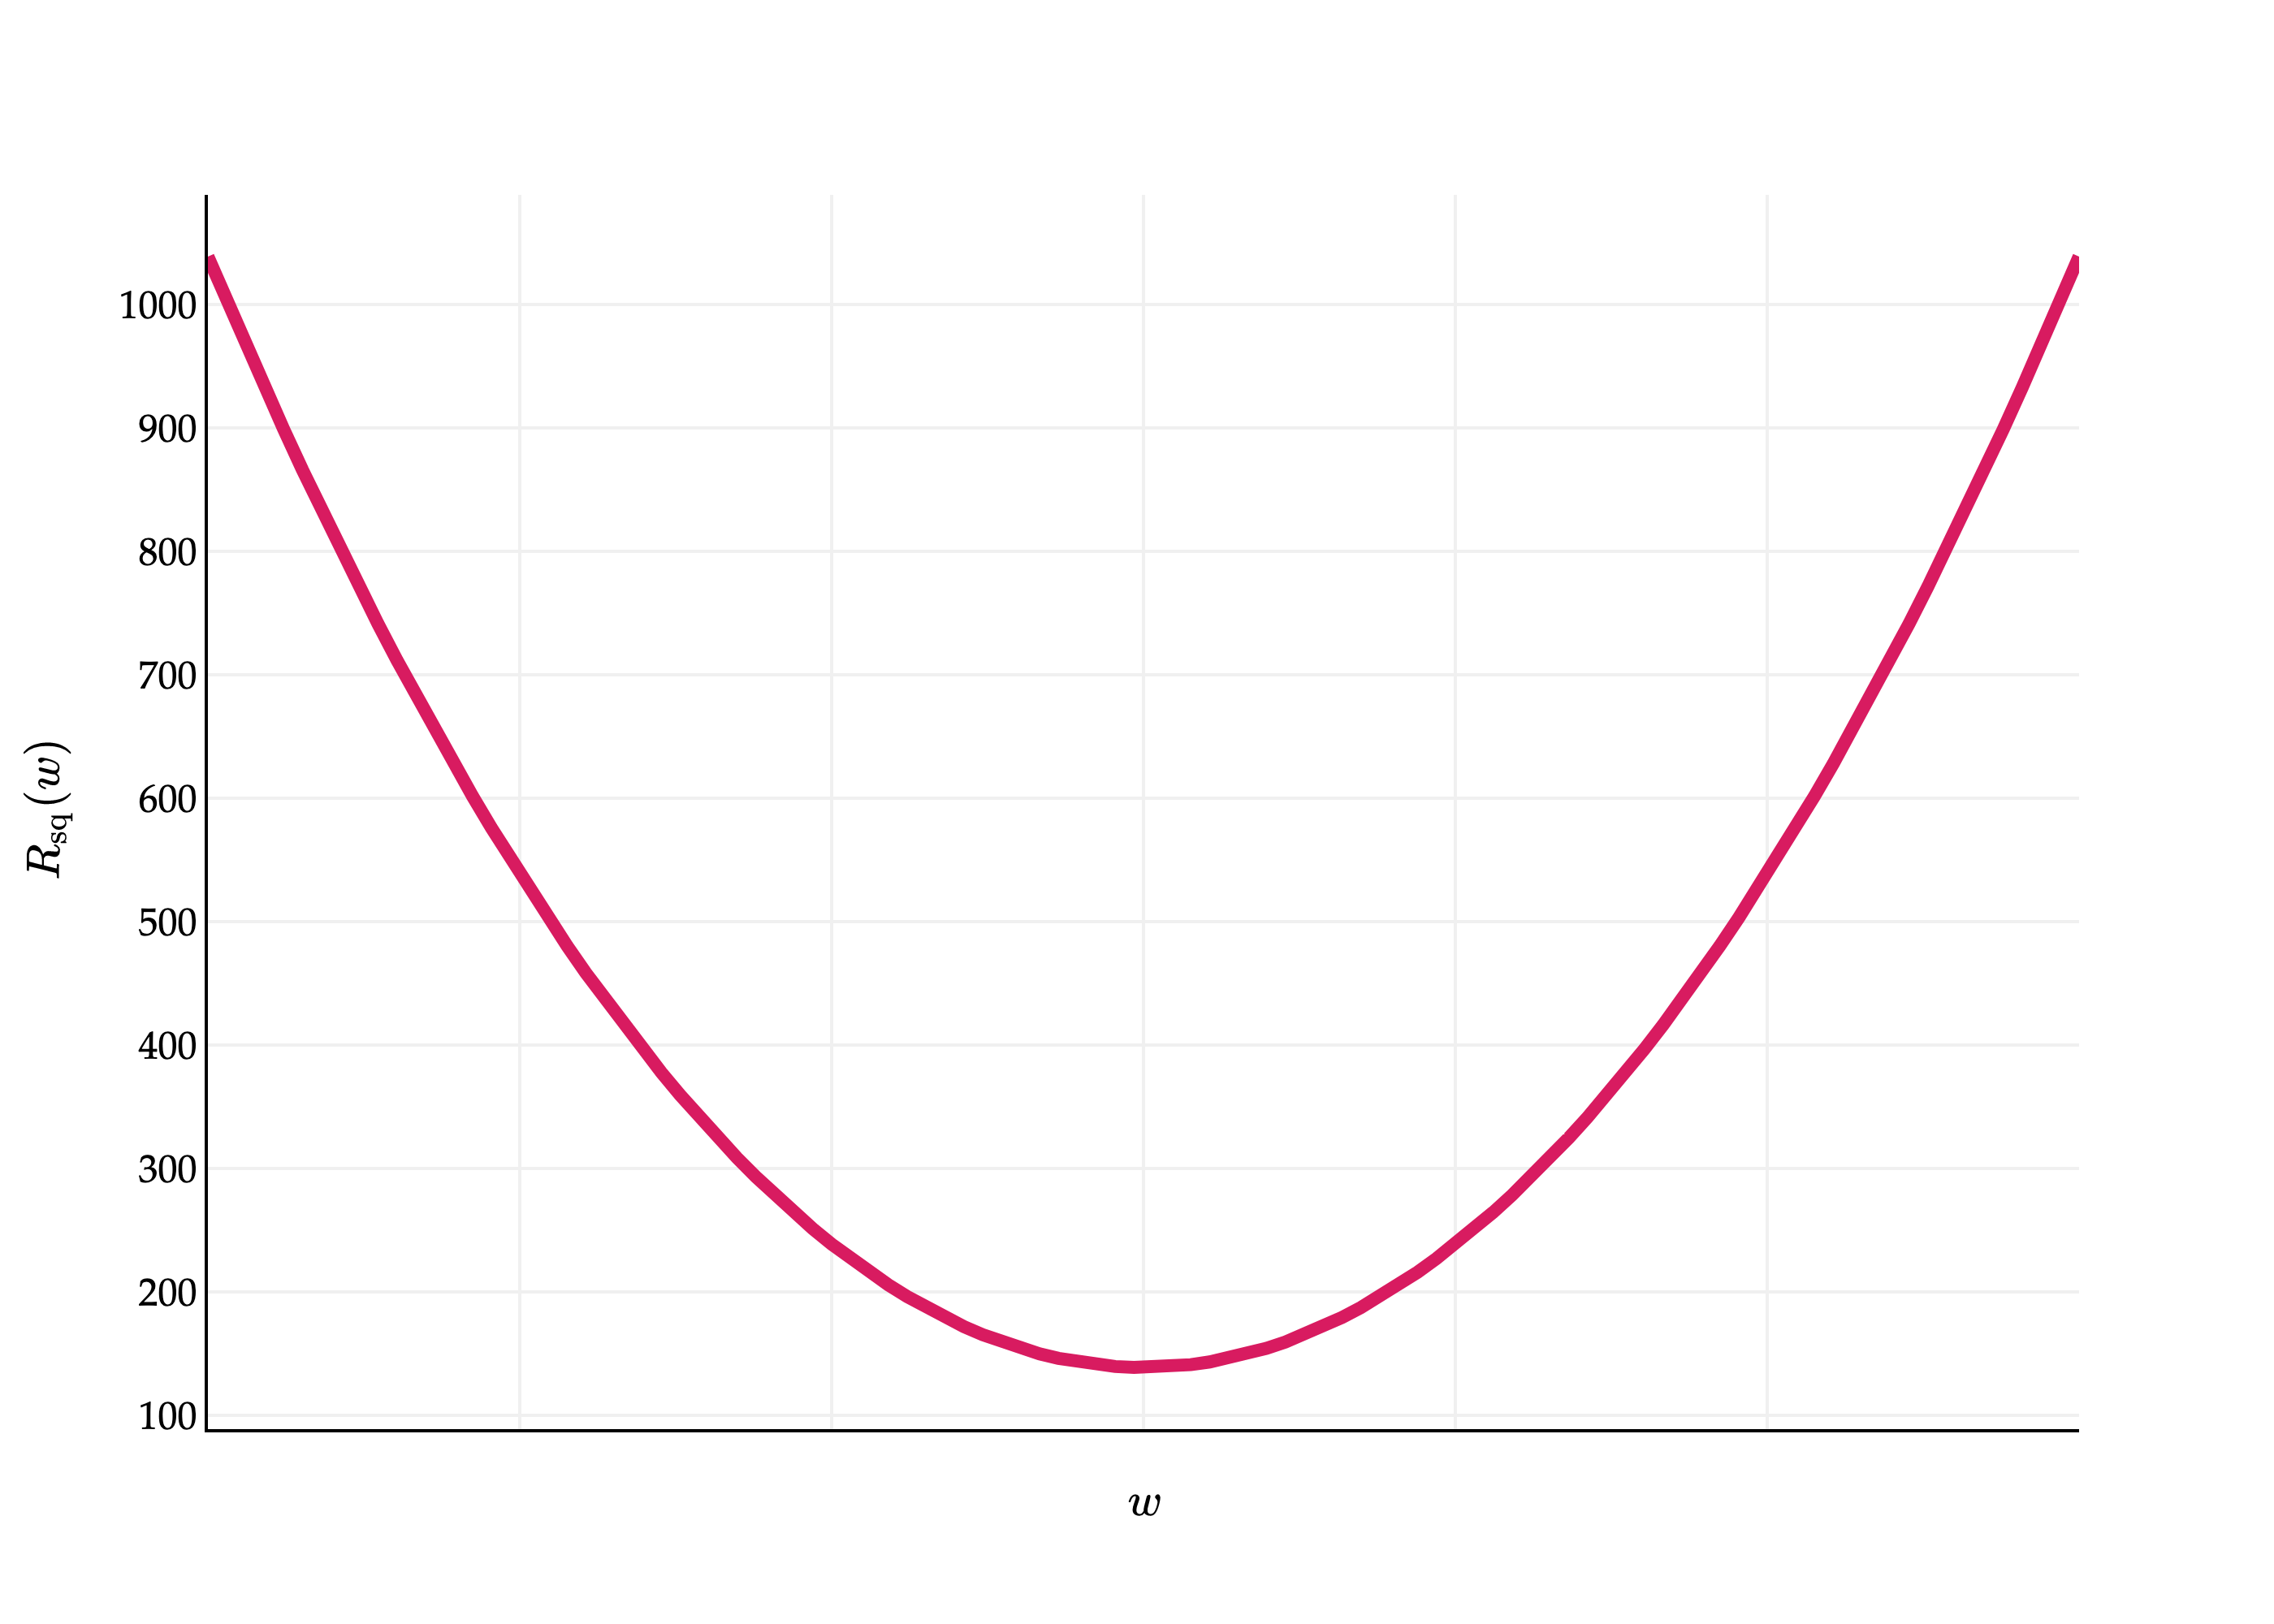

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: ((72-h)**2 + (90-h)**2 + (61-h)**2 + (85-h)**2 + (92-h)**2) / 5

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

fig.update_xaxes(
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{sq}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.show(renderer='png', scale=4)

The question is, though, **what is the $w$-value of the vertex of this parabola**? That is, which $w$ minimizes $R_\text{sq}(w)$?

Before we find the answer, let's cast our problem in more general terms, so that the answer is applicable to any dataset. Suppose we have a dataset of $n$ actual commute times, $y_1, y_2, \ldots, y_n$. Our goal is to find the $w$ that minimizes:

$$\begin{aligned}
R_\text{sq}(w) &= \frac{1}{n} \left((y_1- w)^2 + (y_2 - w)^2 ... + (y_n - w)^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^n (y_i- w)^2
\end{aligned}$$

While it looks like there are many variables in this equation, we know the actual values in the dataset, so we can treat $y_1, y_2, \ldots, y_n$ as constants. The only true variable is $w$.

How do we minimize $R_\text{sq}(w)$? There are a few approaches. We'll use a calculus-based approach here, though in Homework 1 you'll look at an alternative approach. For a refresher on the relevant calculus ideas, see [Appendix 2](../00_math_foundations/02-derivatives.ipynb).

$R_\text{sq}(w)$ is a function of a single variable, $w$. To minimize a function of a single variable, we should:

1. Take the derivative of $R_\text{sq}(w)$ with respect to $w$.
2. Set the derivative equal to 0 and solve for $w$.
3. Verify that the second derivative at the critical point is positive.

Let's go through these steps one by one. The video below walks through these steps as well, but was recorded for a different class, so the notation is slightly different (it uses $h$ instead of $w$).

<iframe width="560" height="315" src="https://www.youtube.com/embed/NSIEP74ifyg?si=N4eoId88k9cCSR1W" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

<!-- __Step 0: The derivative of $(y_i-w)^2$__<br>
In order to find the derivative of $R_\text{sq}(w)$, we'll first need to find the derivative of $(y_i-w)^2$. 
$$
\begin{aligned}
&\frac{\text{d}}{\text{d}w}(y_i-w)^2 \\
&= 2(y_i-w) \cdot \frac{\text{d}}{\text{d}w}(y_i-w) && \text{(chain rule)} \\
&= 2(y_i-w) \cdot (-1) \\
&= -2(y_i-w) 
\end{aligned}
$$ -->

**Step 1: Take the derivative of $R_\text{sq}(w)$ with respect to $w$**

$$\begin{align*}R_\text{sq}(w) &= \frac{1}{n} \sum_{i = 1}^n (y_i - w)^2 \\
\frac{\text{d}}{\text{d}w}R_\text{sq}(w) &= \frac{\text{d}}{\text{d}w}\left(\frac{1}{n} \sum_{i = 1}^n (y_i - w)^2\right) \end{align*}$$

Remember that constants can be pulled out of derivatives, e.g. the derivative of $2 f(x)$ is $2$ times the derivative of $f(x)$.

$$\begin{align*}
\frac{\text{d}}{\text{d}w}R_\text{sq}(w) &= \frac{1}{n} \left( \frac{\text{d}}{\text{d}w} \sum_{i = 1}^n (y_i - w)^2 \right)\end{align*}$$

From here, we'll use the fact that the derivative of a sum is the sum of derivatives, to "push" the derivative operator inside the sum.

$$\begin{align*}
\frac{\text{d}}{\text{d}w}R_\text{sq}(w) &= \frac{1}{n} \sum_{i = 1}^n \frac{\text{d}}{\text{d}w} (y_i - w)^2
\end{align*}$$

What is $\frac{\text{d}}{\text{d}w} (y_i - w)^2$? Try and work it out on your own, then check the solution below.

:::{seealso} Solution
:class: dropdown

The chain rule and power rule are our friends here:

$$\begin{align*}
\frac{\text{d}}{\text{d}w} (y_i - w)^2 &= 2(y_i - w) \cdot \frac{\text{d}}{\text{d}w}(y_i - w) \\
&= 2(y_i - w) \cdot (-1) \\
&= -2(y_i - w)
\end{align*}$$
:::

Using that result, we have:

$$\begin{align*}
\frac{\text{d}}{\text{d}w}R_\text{sq}(w) &= \frac{1}{n} \sum_{i = 1}^n (-2(y_i - w))
\end{align*}$$

Finally, we'll pull the constant of -2 out of the sum.

$$\boxed{\begin{align*}
\frac{\text{d}}{\text{d}w}R_\text{sq}(w) &= - \frac{2}{n} \sum_{i = 1}^n (y_i - w)
\end{align*}}$$

We _could_ simplify this further, but this form will do just fine. Don't forget, though, that the expression on the right side is a function of $w$.

**Step 2: Set the derivative equal to 0 and solve for $w$**

$$- \frac{2}{n} \sum_{i = 1}^n (y_i - w) = 0$$

First, we'll multiply both sides by $-\frac{n}{2}$ to get rid of the fraction.

$$\sum_{i = 1}^n (y_i - w) = 0$$

Separating the sum into two parts gives us:

$$\sum_{i = 1}^n y_i - \sum_{i = 1}^n w = 0$$

$\displaystyle \sum_{i = 1}^n y_i$ can't be broken down much further. But, $\displaystyle \sum_{i = 1}^n w$ is the sum of $n$ copies of $w$, i.e. $w + w + \ldots + w$. This is just $nw$!

$$\sum_{i = 1}^n y_i - nw = 0$$

Adding $nw$ to both sides, then dividing both sides by $n$, gives us:

$$\boxed{w^* = \frac{1}{n} \sum_{i = 1}^n y_i}$$

The value of $w$ that minimizes $R_\text{sq}(w)$ is $w^* = \frac{1}{n} \sum_{i = 1}^n y_i$. Notice that I've called it $w^*$; think of "star" as meaning "best" or "optimal".

The formula for $w^*$ should look very familar. It's the mean of $y_1, y_2, \ldots, y_n$!

**Step 3: Verify that the second derivative at the critical point is positive**

We already know that $R_\text{sq}(w)$ is a parabola, which means that its only critical point is a global minimum. But, we'll be thorough just to set a good example.

Here, we'll need to find the second derivative of $R_\text{sq}(w)$ with respect to $w$.

$$\begin{align*}
\frac{\text{d}^2}{\text{d}w^2}R_\text{sq}(w) &= \frac{\text{d}}{\text{d}w} \left( - \frac{2}{n} \sum_{i = 1}^n (y_i - w) \right) \\
&= - \frac{2}{n} \sum_{i = 1}^n \frac{\text{d}}{\text{d}w} (y_i - w) \\
&= - \frac{2}{n} \sum_{i = 1}^n (-1) \\
&= - \frac{2}{n} (-n) \\
&= 2
\end{align*}$$

The second derivative is 2 for all values of $w$, including at the $w^*$ we found. This tells us that $R_\text{sq}(w)$ is concave opening upwards across its entire domain, so the critical point we've found corresponds to a global minimum.

---

## Conclusion

What was the point of all of that algebra? To recap:

- We decided to use the constant model, $h(x_i) = w$, to make predictions.
- To find the best value of $w$ – a model parameter • we decided to minimize mean squared error:
    $$R_\text{sq}(w) = \frac{1}{n} \sum_{i = 1}^n (y_i - w)^2$$
- Using calculus, we found that the value of $w$ that minimizes $R_\text{sq}(w)$ is $$w^* = \frac{1}{n} \sum_{i = 1}^n y_i = \text{Mean}(y_1, y_2, \ldots, y_n)$$

In other words, **the mean minimizes mean squared error**. This is a remarkable result. We use the mean all of the time in daily life, and now we've proven that it is **optimal** in some sense. It is the constant with the smallest mean squared error, no matter the dataset we're working with.

Another name for $w^*$ is an **optimal model parameter**. In the context of our full commute times dataset, the optimal model parameter is the mean commute time. Visually, the value of $w^* \approx 73$ tells us the optimal "height" at which we should draw the constant model, $h(x_i) = w$.

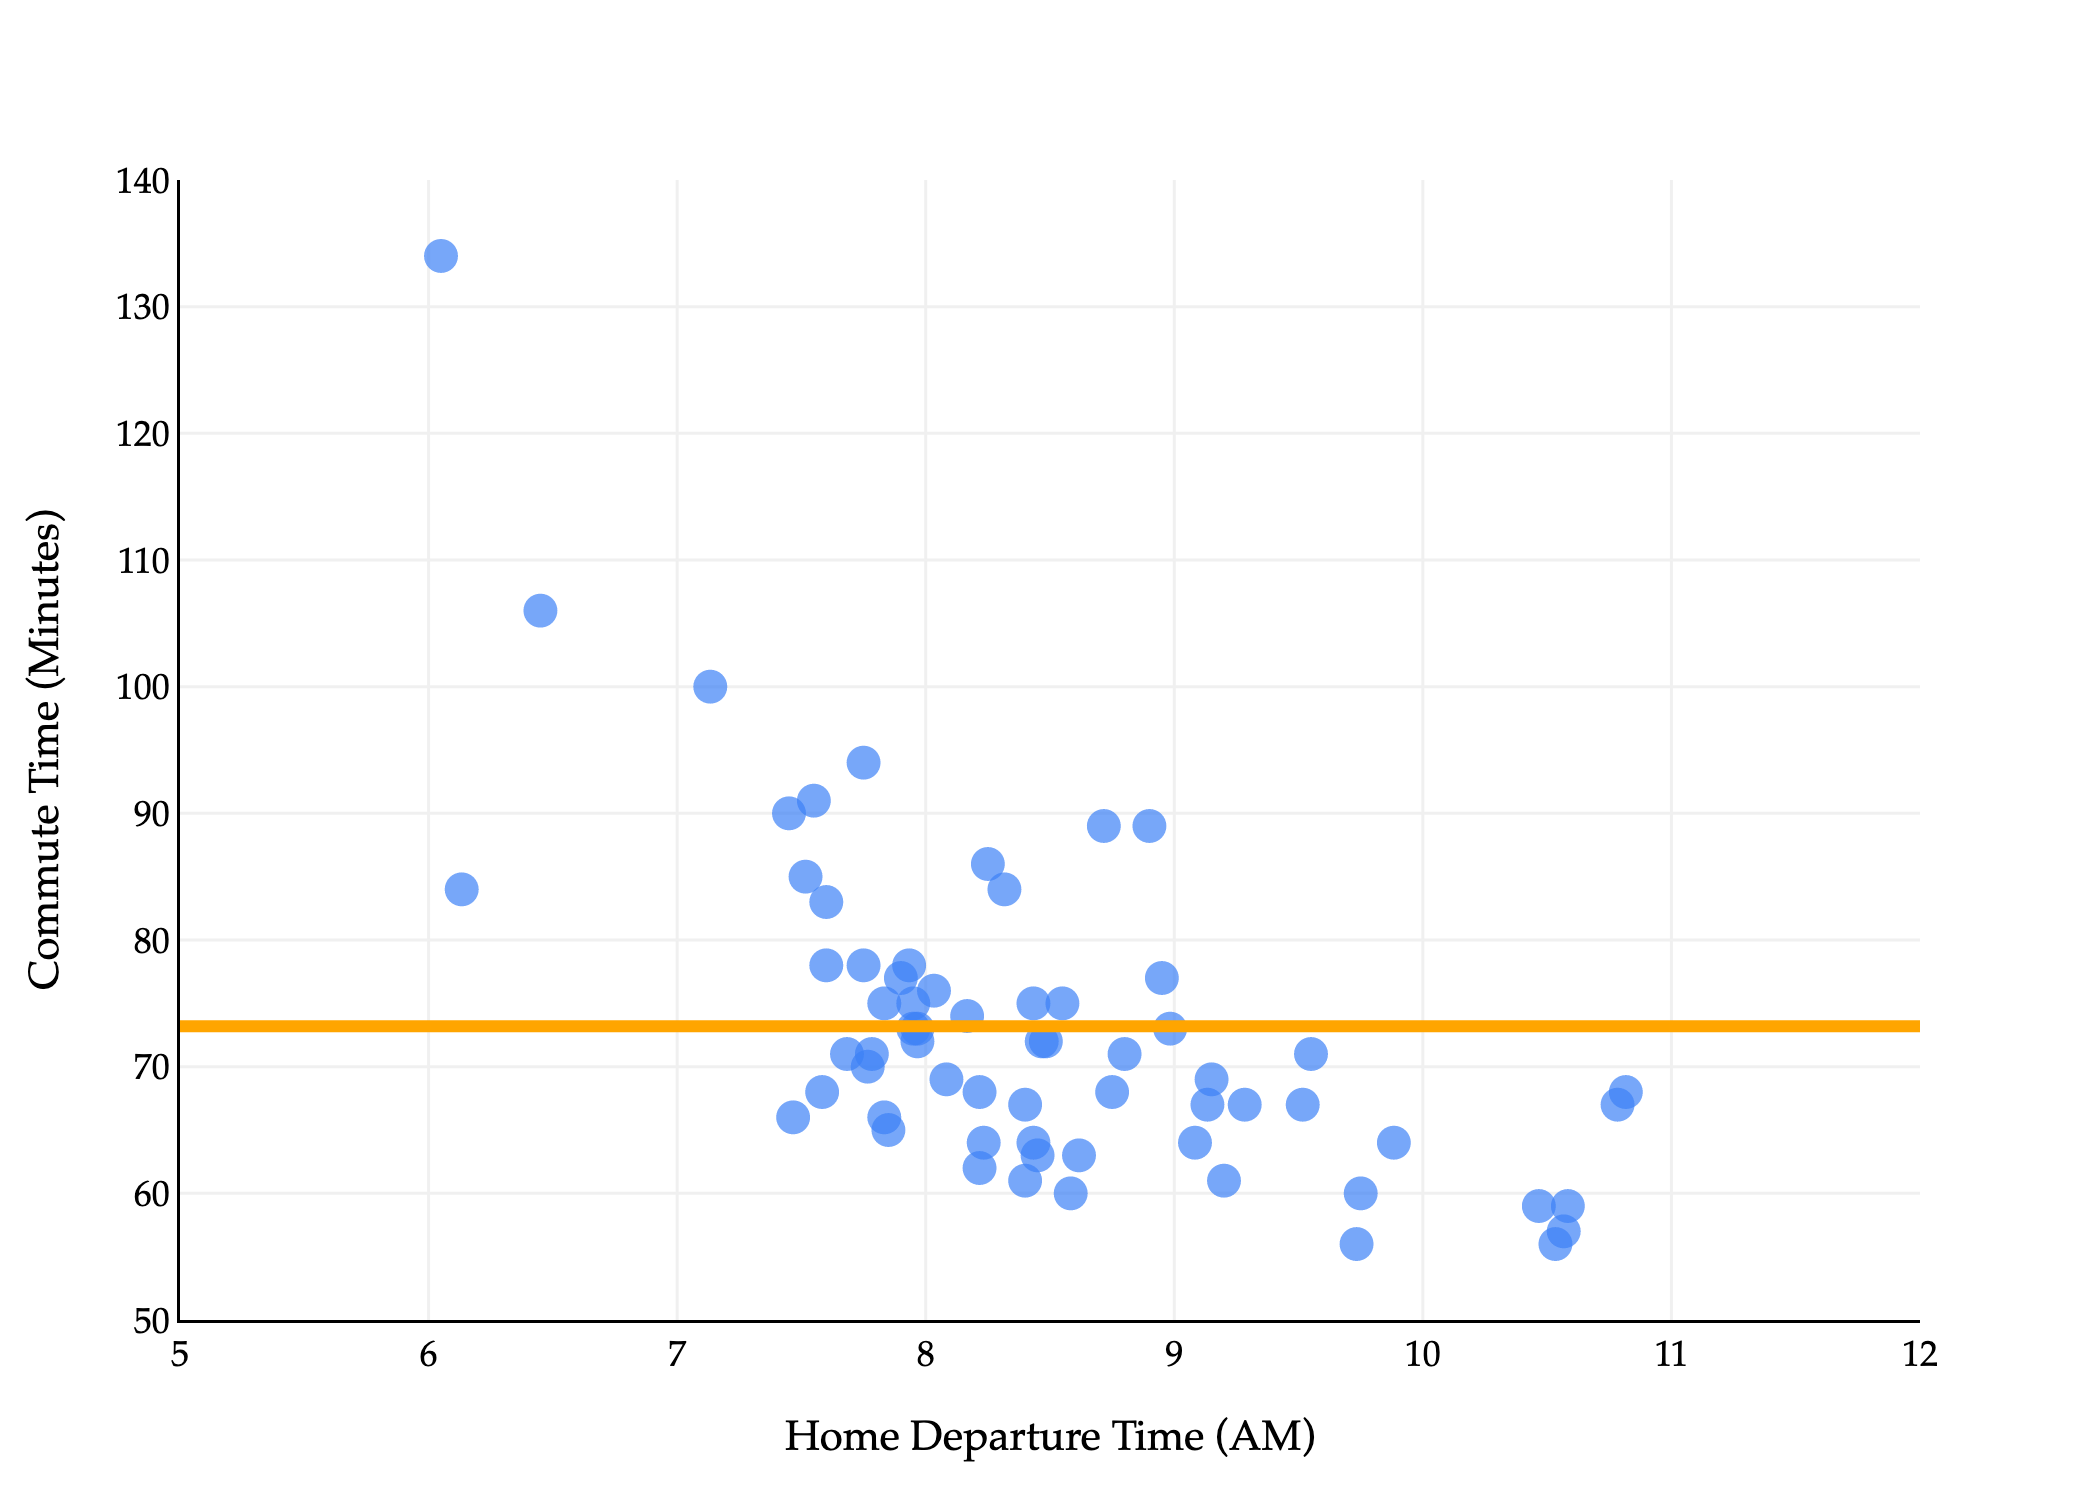

In [54]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')
y_mean = df['minutes'].mean()

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)

fig.add_hline(
    y=y_mean,
    line_color='orange',
    line_width=4
)

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[5, 12]
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False,
)
fig.show(renderer='png', scale=3)


Is this the best possible model? No, of course not – we're not capturing the fact that later departure times are associated with shorter commute times. But as a first attempt at building a model, the constant model is valuable. If someone asked you how long your commutes are, saying something like "about 73 minutes" is reasonable.

What's next?
- In [Chapter 1.3](03-absolute-loss.ipynb), we'll investigate other loss functions, like absolute loss.
- In [Chapter 2.1](../02_simple_linear_regression/01-overview.ipynb), we'll reintroduce the simple linear regression model, $h(x_i) = w_0 + w_1 x_i$, and see how to find the best values of $w_0$ and $w_1$.